# 🧭 Embeddings and Semantic Search — Retrieval That Understands Meaning

> **What you'll learn:** what embeddings are and how to compare them, how sentence-transformer models turn text into vectors, bi-encoders vs cross-encoders, how to choose a model, semantic search from scratch, BM25 and hybrid search with reciprocal rank fusion, reranking, FAISS indexes, quantization and Matryoshka truncation, clustering, fine-tuning — and, above all, how to **measure** retrieval quality with recall@k, MRR, and nDCG. This is the retrieval foundation of every RAG system.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate (two 🔴 sections) |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Classical NLP](01_Classical_NLP.ipynb) (TF-IDF, word2vec) · [Transformers From Scratch](../04_Deep_Learning/03_Transformers_From_Scratch.ipynb) (attention, token embeddings) |
| **Tested with** | Python 3.12 · sentence-transformers 6.0 · transformers 5.17 · torch 2.14 · faiss-cpu 1.15 · bm25s 0.3 · scikit-learn 1.9 |
| **Interview relevance** | ⭐⭐⭐ Very high — "design semantic search / the retrieval half of RAG", bi- vs cross-encoder, HNSW vs IVF, hybrid search, recall@k / MRR / nDCG, "how would you fine-tune an embedding model?" |

## 🤔 What Is an Embedding?

An **embedding** is a list of numbers (a **vector**) that represents a piece of text so that **similar meanings end up close together**.

Imagine a huge library where books are shelved by *topic*, not by title. A book about "heart attacks" sits right next to one about "myocardial infarction", even though they share no words. To find books like yours, you walk to where yours would stand and look at the neighbours. An embedding model is the librarian that decides each book's position; **semantic search** is walking to the right shelf.

```
 "How do I reset my password?"      → [ 0.12, -0.40,  0.33, … ]  ┐ close together
 "I forgot my login credentials"    → [ 0.10, -0.38,  0.29, … ]  ┘ (similar meaning)
 "The Oilers won in overtime"       → [-0.51,  0.22, -0.07, … ]    far away
```

In the [previous notebook](01_Classical_NLP.ipynb) word2vec gave one vector per **word**. Here we use transformer models that produce one vector per **sentence or passage**, which is what search needs.

## 🎯 Why It Matters

- **RAG runs on retrieval.** A retrieval-augmented LLM can only answer from the passages you retrieve. If retrieval misses the right passage, no prompt engineering can save the answer. Embeddings + an index + a reranker is the standard retrieval stack.
- **Search, recommendations, deduplication, clustering, classification** — anything that asks "what is similar to this?" uses embeddings.
- **Engineering trade-offs are real money:** a 100-million-vector index at 1024 float32 dimensions needs ~400 GB of RAM; binary quantization cuts that 32×. Choosing Flat vs HNSW vs IVF decides your latency.
- **In interviews** (AI engineer, ML engineer, search/RAG roles) expect: "design the retrieval layer for a RAG system", "bi-encoder vs cross-encoder?", "how does HNSW work and what are its knobs?", "why hybrid search?", "how do you evaluate retrieval?", "how would you fine-tune an embedding model on your domain?". This notebook answers each with code and measurements on a real benchmark.

## ✅ By the End You Can

- [ ] Explain cosine, dot product, and Euclidean similarity, pooling, and bi-encoders vs cross-encoders
- [ ] Build semantic search from scratch in NumPy and evaluate it with recall@k, MRR, and nDCG@k you implemented yourself
- [ ] Combine BM25 and dense retrieval with reciprocal rank fusion, and test whether a cross-encoder reranker actually helps
- [ ] Choose a FAISS index (Flat, HNSW, IVF) from a measured speed-vs-recall trade-off, and shrink embeddings with quantization and Matryoshka truncation
- [ ] Fine-tune an embedding model with `SentenceTransformerTrainer` and `MultipleNegativesRankingLoss` and prove the gain on held-out queries
- [ ] Design and defend a retrieval pipeline with numbers: quality, latency, and memory

## 📋 Table of Contents

1. [Embedding Geometry: Cosine, Dot Product, Euclidean](#1.-Embedding-Geometry:-Cosine,-Dot-Product,-Euclidean-🟢)
2. [Word, Contextual, and Sentence Embeddings](#2.-Word,-Contextual,-and-Sentence-Embeddings-🟢)
3. [Pooling: From Token Vectors to One Vector](#3.-Pooling:-From-Token-Vectors-to-One-Vector-🟡)
4. [Sentence Transformers in Practice](#4.-Sentence-Transformers-in-Practice-🟢)
5. [Bi-Encoders vs Cross-Encoders](#5.-Bi-Encoders-vs-Cross-Encoders-🟡)
6. [Choosing a Model: MTEB, Size, and Prompts](#6.-Choosing-a-Model:-MTEB,-Size,-and-Prompts-🟢)
7. [Semantic Search From Scratch in NumPy](#7.-Semantic-Search-From-Scratch-in-NumPy-🟢)
8. [Evaluating Retrieval: Recall@k, MRR, nDCG](#8.-Evaluating-Retrieval:-Recall@k,-MRR,-nDCG-🟡)
9. [BM25 and Hybrid Search With Reciprocal Rank Fusion](#9.-BM25-and-Hybrid-Search-With-Reciprocal-Rank-Fusion-🟡)
10. [Reranking With a Cross-Encoder](#10.-Reranking-With-a-Cross-Encoder-🟡)
11. [Approximate Nearest Neighbour Search With FAISS](#11.-Approximate-Nearest-Neighbour-Search-With-FAISS-🔴)
12. [Quantization and Matryoshka Embeddings](#12.-Quantization-and-Matryoshka-Embeddings-🟡)
13. [Clustering and Visualizing Embeddings](#13.-Clustering-and-Visualizing-Embeddings-🟢)
14. [Fine-Tuning an Embedding Model](#14.-Fine-Tuning-an-Embedding-Model-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-SciFact-Search-Engine-Shoot-Out) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

**Hardware:** everything runs on a laptop CPU; Apple-Silicon **MPS** or an NVIDIA **CUDA** GPU is used automatically when available (encoding the benchmark corpus takes ~10–40 s per model on MPS).

**Downloads (first run only, ~490 MB, cached afterwards):** the BEIR SciFact benchmark (~5 MB), a 24 MB slice of BEIR Quora, 20 Newsgroups (~14 MB, cached if you ran the previous notebook), and five small models: `all-MiniLM-L6-v2` (91 MB), `bge-small-en-v1.5` (134 MB), `static-retrieval-mrl-en-v1` (125 MB), and the `ms-marco-MiniLM-L6-v2` cross-encoder (91 MB).

**About FAISS on macOS:** the pip wheels of `faiss-cpu` and `torch` each bundle their *own* OpenMP runtime (`libomp.dylib`). Loading both into one Python process aborts with `OMP: Error #15` (and the "unsafe" `KMP_DUPLICATE_LIB_OK=TRUE` workaround segfaulted in our tests). So this notebook never imports `faiss` in the kernel: section 11 runs FAISS in a **separate Python process** that only needs NumPy. That mirrors production anyway — the vector index is usually its own service.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "sentence-transformers>=5" "transformers>=4.51" torch "faiss-cpu>=1.8" "bm25s>=0.2" PyStemmer datasets scikit-learn matplotlib pandas

import gc
import json
import math
import subprocess
import sys
import tempfile
import time
from pathlib import Path

import bm25s
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sentence_transformers
import sklearn
import Stemmer
import torch
import transformers
from datasets import load_dataset
from huggingface_hub.utils import logging as hf_logging
from sentence_transformers import CrossEncoder, SentenceTransformer
from transformers.utils import logging as transformers_logging

print(f"Python {sys.version.split()[0]} | sentence-transformers {sentence_transformers.__version__} | "
      f"transformers {transformers.__version__} | torch {torch.__version__} | bm25s {bm25s.__version__} | scikit-learn {sklearn.__version__}")

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

hf_logging.set_verbosity_error()                       # hide the Hub's anonymous-download notice (set HF_TOKEN for higher limits)
transformers_logging.disable_progress_bar()            # hide the per-load "Loading weights" bar

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
pd.set_option("display.max_colwidth", 90)
OUTPUT_DIR = Path("_outputs")                          # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def free_memory():
    gc.collect()
    if DEVICE == "mps":
        torch.mps.empty_cache()
    elif DEVICE == "cuda":
        torch.cuda.empty_cache()


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    exp_arr = np.asarray(expected, dtype=object)
    numeric = all(isinstance(x, (int, float, np.integer, np.floating)) and not isinstance(x, bool) for x in exp_arr.ravel())
    if numeric:
        try:
            got_arr = np.asarray(got, dtype=float)
            ok = got_arr.shape == exp_arr.shape and np.allclose(got_arr, exp_arr.astype(float), rtol=1e-5, atol=1e-6)
        except (TypeError, ValueError):
            ok = False
    else:
        ok = list(got) == list(expected) if isinstance(expected, (list, tuple)) else got == expected
    assert ok, f"❌ {name}: got {got!r} — not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | sentence-transformers 6.0.1 | transformers 5.17.0 | torch 2.14.0 | bm25s 0.3.11 | scikit-learn 1.9.1
device: mps


## 1. Embedding Geometry: Cosine, Dot Product, Euclidean 🟢

Three ways to compare vectors $a$ and $b$:

| Measure | Formula | Looks at | Range |
|---|---|---|---|
| **Dot product** | $a \cdot b = \sum_i a_i b_i$ | direction **and** length | any number |
| **Cosine similarity** | $\dfrac{a \cdot b}{\lVert a\rVert\,\lVert b\rVert}$ | direction only (the angle) | −1 to 1 |
| **Euclidean distance** | $\lVert a - b\rVert$ | straight-line distance | 0 to ∞ (smaller = closer) |

**The one rule to remember:** if every vector is **L2-normalized** (scaled to length 1), the three give the **same ranking**, because
$$\lVert a - b\rVert^2 = \lVert a\rVert^2 + \lVert b\rVert^2 - 2\,a\cdot b = 2 - 2\cos(a, b).$$
That's why most embedding pipelines normalize once and then use the fastest operation: a dot product.

In [2]:
vecs = rng.normal(size=(1000, 64))
query = rng.normal(size=64)

dot_rank = np.argsort(-(vecs @ query))
cos = (vecs @ query) / (np.linalg.norm(vecs, axis=1) * np.linalg.norm(query))
cos_rank = np.argsort(-cos)
euc_rank = np.argsort(np.linalg.norm(vecs - query, axis=1))
print("raw vectors  — top-5 by dot:", dot_rank[:5], "| cosine:", cos_rank[:5], "| euclidean:", euc_rank[:5])

unit = vecs / np.linalg.norm(vecs, axis=1, keepdims=True)
q_unit = query / np.linalg.norm(query)
same = (np.array_equal(np.argsort(-(unit @ q_unit)), np.argsort(np.linalg.norm(unit - q_unit, axis=1))))
print("normalized   — dot ranking == euclidean ranking:", same)
print("identity check ‖a−b‖² = 2 − 2cos:", np.allclose(np.linalg.norm(unit - q_unit, axis=1) ** 2, 2 - 2 * unit @ q_unit))

raw vectors  — top-5 by dot: [657 776 869 936 861] | cosine: [657 776 869 901 936] | euclidean: [657 776   1 847 901]
normalized   — dot ranking == euclidean ranking: True
identity check ‖a−b‖² = 2 − 2cos: True


**What does the angle mean for text?** A cosine of 1 means "same direction". It is tempting to say −1 (180°) means "opposite meaning" — but embedding models are not trained to put antonyms at opposite ends. "I love this movie" and "I hate this movie" are *about the same thing*, so they usually score **high**. Let's look at real sentence embeddings.

In [3]:
minilm = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)
pairs = [("I love this movie", "I hate this movie"),
         ("How do I reset my password?", "I forgot my login credentials"),
         ("How do I reset my password?", "The Oilers won in overtime")]
for a, b in pairs:
    ea, eb = minilm.encode([a, b], normalize_embeddings=True)
    print(f"cos = {ea @ eb:+.3f}  angle = {np.degrees(np.arccos(np.clip(ea @ eb, -1, 1))):5.1f}°  | {a!r} vs {b!r}")

cos = +0.715  angle =  44.4°  | 'I love this movie' vs 'I hate this movie'
cos = +0.678  angle =  47.3°  | 'How do I reset my password?' vs 'I forgot my login credentials'
cos = +0.159  angle =  80.8°  | 'How do I reset my password?' vs 'The Oilers won in overtime'


Look at the first pair: opposite sentiment, yet a high cosine. Similarity means "related / about the same thing", not "agrees with". If you need to separate positive from negative, you need a classifier or a model trained for that. (Section 7 measures what scores look like across a whole real corpus.)

### ✍️ Your Turn

Normalize `u` and `v` to unit length, then compute their dot product. Store it in `cos_uv` (it equals the cosine similarity).

In [4]:
u = np.array([3.0, 4.0])
v = np.array([4.0, 3.0])
cos_uv = None  # TODO: your code here
check("cos_uv", cos_uv, 0.96, hint="u / np.linalg.norm(u) has length 1; then take the dot product with v's unit vector.")

⏳ cos_uv: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
u = np.array([3.0, 4.0])
v = np.array([4.0, 3.0])
cos_uv = float((u / np.linalg.norm(u)) @ (v / np.linalg.norm(v)))
check("cos_uv", cos_uv, 0.96)
```
Both vectors have length 5, and 3·4 + 4·3 = 24, so the cosine is 24/25 = 0.96.
</details>

> 💡 **Interview angle:** "Cosine or dot product?" — if the model normalizes its outputs (most sentence-transformers retrieval models do), they're identical and dot product is faster. If not, dot product rewards long vectors, which some models use on purpose (e.g. trained with dot-product loss) — use the similarity the model was trained with.

## 2. Word, Contextual, and Sentence Embeddings 🟢

| Kind | One vector per… | Example | Problem it solves |
|---|---|---|---|
| **Static word embedding** | word type (same vector everywhere) | word2vec, GloVe | synonyms for bag-of-words |
| **Contextual token embedding** | token *occurrence* (depends on the sentence) | BERT's hidden states | word senses, context |
| **Sentence embedding** | whole sentence / passage | sentence-transformers models | comparing texts for search |

A transformer outputs one vector for **every token**, and those vectors already depend on the surrounding words. Let's check that "bank" gets different vectors in different sentences.

In [5]:
from transformers import AutoModel, AutoTokenizer

hf_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
hf_model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2").eval()     # plain BERT-style encoder on CPU

bank_sentences = ["We sat on the bank of the river and watched the boats.",
                  "The river bank was muddy after the rain.",
                  "I deposited my salary at the bank this morning.",
                  "The bank approved the loan application."]
batch = hf_tokenizer(bank_sentences, padding=True, return_tensors="pt")
with torch.no_grad():
    token_vectors = hf_model(**batch).last_hidden_state                                   # (sentences, tokens, 384)
print("token embeddings shape:", tuple(token_vectors.shape))

bank_id = hf_tokenizer.convert_tokens_to_ids("bank")
bank_vecs = torch.stack([token_vectors[i][batch["input_ids"][i] == bank_id][0] for i in range(len(bank_sentences))])
bank_vecs = torch.nn.functional.normalize(bank_vecs, dim=-1)
sims = (bank_vecs @ bank_vecs.T).numpy()
labels = ["river-1", "river-2", "money-1", "money-2"]
display(pd.DataFrame(sims, index=labels, columns=labels).round(3))
same_sense = (sims[0, 1] + sims[2, 3]) / 2
cross_sense = sims[:2, 2:].mean()
print(f"avg similarity of 'bank' — same sense: {same_sense:.3f} | different sense: {cross_sense:.3f}")

token embeddings shape: (4, 15, 384)


,river-1,river-2,money-1,money-2
river-1,1.000,0.887,0.804,0.766
river-2,0.887,1.000,0.798,0.799
money-1,0.804,0.798,1.000,0.847
money-2,0.766,0.799,0.847,1.000


avg similarity of 'bank' — same sense: 0.867 | different sense: 0.792


Contextual vectors separate the two senses, which a single word2vec vector for "bank" cannot do. But for search we need **one** vector per text — that's what pooling does.

> 💡 **Interview angle:** "Why not use BERT's raw output for sentence similarity?" — BERT was pre-trained for masked-token prediction, not for making sentence vectors comparable. The SBERT paper found averaged GloVe vectors beat BERT's CLS vector on STS benchmarks; you need a model fine-tuned for similarity (a sentence-transformer).

## 3. Pooling: From Token Vectors to One Vector 🟡

**Pooling** collapses a `(tokens, dim)` matrix into one `(dim,)` vector:

- **Mean pooling** — average all real tokens. **Padding tokens must be excluded** using the attention mask (1 = real token, 0 = padding).
- **CLS pooling** — take the vector of the first special token `[CLS]`; works when the model was trained that way (e.g. BGE).
- **Max pooling** — take the maximum of each dimension; rarely used now.

```
tokens:   [CLS]  how   do   i   reset  [SEP]  [PAD] [PAD]
mask:       1     1     1   1     1      1      0     0
mean pool = sum(vectors × mask) / sum(mask)        ← PADs contribute nothing
```

A sentence-transformers model is just a list of modules — the transformer, then pooling, then (often) normalization. Print them to see which pooling a model uses:

In [6]:
print(minilm)
bge_config_model = SentenceTransformer("BAAI/bge-small-en-v1.5", device="cpu")
print("\nbge-small pooling:", bge_config_model[1])
del bge_config_model
free_memory()

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
)



bge-small pooling: Pooling({'embedding_dimension': 384, 'pooling_mode': 'cls', 'include_prompt': True})


`all-MiniLM-L6-v2` uses **mean** pooling, `bge-small-en-v1.5` uses **CLS** pooling, and both end with `Normalize`, so their embeddings have length 1. You'll reproduce mean pooling by hand in 🔧 Build It From Scratch.

### ✍️ Your Turn

Given token embeddings of shape `(2 sentences, 3 tokens, 2 dims)`, return the **CLS pooled** vectors (the first token of each sentence) as an array of shape `(2, 2)`.

In [7]:
toy_tokens = np.array([[[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]],
                       [[2.0, 0.0], [4.0, 2.0], [100.0, 100.0]]])
cls_pooled = None  # TODO: your code here
check("cls_pooled", cls_pooled, [[1.0, 2.0], [2.0, 0.0]], hint="Index the token axis: toy_tokens[:, 0, :]")

⏳ cls_pooled: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
toy_tokens = np.array([[[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]],
                       [[2.0, 0.0], [4.0, 2.0], [100.0, 100.0]]])
cls_pooled = toy_tokens[:, 0, :]
check("cls_pooled", cls_pooled, [[1.0, 2.0], [2.0, 0.0]])
```
Practice exercise 5 asks for the harder version: masked mean pooling.
</details>

> 💡 **Interview angle:** "Mean or CLS pooling?" — use whatever the model was trained with (it's in `modules.json` / the pooling config). Mixing them up silently degrades quality. For mean pooling, always mask padding, or batches with different lengths give different vectors for the same sentence.

## 4. Sentence Transformers in Practice 🟢

The `sentence-transformers` library wraps tokenization, the transformer, pooling, and normalization in one call. Key APIs in v5–v6:

| API | Use |
|---|---|
| `model.encode(texts)` | embed anything symmetric (clustering, similarity) |
| `model.encode_query(q)` / `model.encode_document(d)` | retrieval — applies the model's query/document **prompts** if it has any |
| `model.similarity(a, b)` | similarity matrix using the model's configured function (`model.similarity_fn_name`) |
| `normalize_embeddings=True`, `batch_size=`, `truncate_dim=`, `precision=` | common knobs |

similarity function: cosine | prompts: {'query': '', 'document': ''}
'I forgot my login credentials'          → 'How do I reset my password?' (0.68)
'Do you take PayPal?'                    → 'What payment methods do you accept?' (0.51)
'my pictures make the application close' → 'The app crashes when I upload a photo.' (0.58)


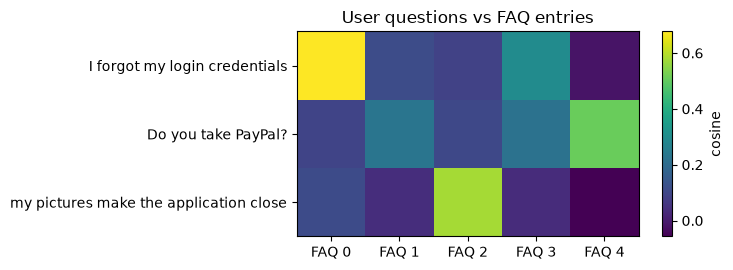

In [8]:
faq = ["How do I reset my password?",
       "Where can I download my invoices?",
       "The app crashes when I upload a photo.",
       "Can I change the email address on my account?",
       "What payment methods do you accept?"]
user_questions = ["I forgot my login credentials", "Do you take PayPal?", "my pictures make the application close"]

faq_emb = minilm.encode_document(faq)
question_emb = minilm.encode_query(user_questions)
scores = minilm.similarity(question_emb, faq_emb)                                          # torch tensor (3, 5)
print("similarity function:", minilm.similarity_fn_name, "| prompts:", minilm.prompts)
for q, row in zip(user_questions, scores):
    best = int(row.argmax())
    print(f"{q!r:40} → {faq[best]!r} ({row[best]:.2f})")

fig, ax = plt.subplots(figsize=(7, 2.8))
im = ax.imshow(scores.numpy(), cmap="viridis")
ax.set_xticks(range(len(faq)), [f"FAQ {i}" for i in range(len(faq))])
ax.set_yticks(range(len(user_questions)), user_questions)
fig.colorbar(im, ax=ax, label="cosine")
ax.set_title("User questions vs FAQ entries")
plt.tight_layout()
plt.show()

None of the matching pairs share key words ("credentials" vs "password", "PayPal" vs "payment methods") — exactly where TF-IDF would fail.

> 💡 **Interview angle:** "What's the difference between `encode_query` and `encode_document`?" — for asymmetric retrieval models that were trained with instructions or prefixes (like E5's `query: ` / `passage: `), they prepend the right prompt; for models without prompts they behave like `encode`. Forgetting the prefix on a model that needs it is a classic silent quality bug.

## 5. Bi-Encoders vs Cross-Encoders 🟡

```
  BI-ENCODER (sentence-transformer)              CROSS-ENCODER (reranker)
  query ──► encoder ──► q-vector ┐               [query + document] ──► encoder ──► relevance score
  doc   ──► encoder ──► d-vector ┴► cosine        (both texts attend to each other)
  docs are embedded ONCE, offline                 must run the model for EVERY (query, doc) pair
```

- A **bi-encoder** embeds query and document **separately**. Documents are embedded once and stored; a query needs one forward pass plus a vector search. Scales to billions of documents.
- A **cross-encoder** reads query and document **together**, so every word of the query can attend to every word of the document. More accurate for fine distinctions, but you can't precompute anything: 1 query × 1M docs = 1M forward passes.

So production systems **retrieve with a bi-encoder** (fast, top-100) and **rerank with a cross-encoder** (slow, only those 100).

**How were these models trained?** The original Sentence-BERT (Reimers & Gurevych, 2019) fine-tuned BERT in a siamese setup on SNLI + MultiNLI with a **softmax classification objective** over the features $(u, v, |u-v|)$, then on STS benchmark data with a **cosine-similarity regression objective** (mean squared error). (A triplet objective appears in the paper for a separate Wikipedia-sections experiment.) Modern retrieval models like `all-MiniLM-L6-v2` were instead trained **contrastively** on over a billion text pairs with **in-batch negatives** — in sentence-transformers that loss is `MultipleNegativesRankingLoss`, which you'll use in section 14.

In [9]:
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2", device=DEVICE)
query_text = "Do you take PayPal?"
candidates = ["What payment methods do you accept?", "Where can I download my invoices?",
              "PayPal is a company founded in 1998.", "Can I change the email address on my account?"]

bi_scores = minilm.similarity(minilm.encode_query([query_text]), minilm.encode_document(candidates))[0].numpy()
ce_scores = cross_encoder.predict([(query_text, c) for c in candidates])
display(pd.DataFrame({"candidate": candidates, "bi-encoder cosine": bi_scores, "cross-encoder score (logit)": ce_scores})
        .sort_values("cross-encoder score (logit)", ascending=False).round(3))

# Cost: how long does each approach take to score 1 query against N documents?
docs_for_cost = [f"document number {i} about payments, invoices and accounts" for i in range(512)]
t0 = time.perf_counter(); doc_matrix = minilm.encode_document(docs_for_cost, batch_size=128); t_index = time.perf_counter() - t0
t0 = time.perf_counter(); _ = minilm.similarity(minilm.encode_query([query_text]), doc_matrix); t_bi = time.perf_counter() - t0
t0 = time.perf_counter(); _ = cross_encoder.predict([(query_text, d) for d in docs_for_cost], batch_size=128); t_ce = time.perf_counter() - t0
print(f"bi-encoder: embed {len(docs_for_cost)} docs once {t_index:.2f}s, then each query {t_bi * 1000:.1f} ms | "
      f"cross-encoder: {t_ce * 1000:.0f} ms per query for the same {len(docs_for_cost)} docs ({t_ce / t_bi:.0f}× slower per query)")

,candidate,bi-encoder cosine,cross-encoder score (logit)
2,PayPal is a company founded in 1998.,0.540,0.625
0,What payment methods do you accept?,0.511,-8.238
1,Where can I download my invoices?,0.228,-11.160
3,Can I change the email address on my account?,0.220,-11.356


bi-encoder: embed 512 docs once 0.21s, then each query 22.1 ms | cross-encoder: 393 ms per query for the same 512 docs (18× slower per query)


Cross-encoder scores are raw **logits**, not probabilities or cosines: only their order matters (apply a sigmoid if you need 0–1). The cross-encoder was trained on MS MARCO web-search data — keep that in mind for section 10.

> 💡 **Interview angle:** "Why not use the cross-encoder for everything?" — it can't precompute document representations, so cost grows with (queries × documents). Use a bi-encoder (plus BM25) for recall over the whole corpus and a cross-encoder for precision on the top-k.

## 6. Choosing a Model: MTEB, Size, and Prompts 🟢

The [MTEB leaderboard](https://huggingface.co/spaces/mteb/leaderboard) (Massive Text Embedding Benchmark) ranks embedding models across retrieval, clustering, classification, and more. Use it to shortlist — then **measure on your own data**, because leaderboard averages hide domain differences.

Small models that run well on a laptop:

| Model | Params | Dim | Max tokens | Pooling | Prompt / prefix |
|---|---|---|---|---|---|
| `sentence-transformers/all-MiniLM-L6-v2` | 22M | 384 | 256 | mean | none |
| `BAAI/bge-small-en-v1.5` | 33M | 384 | 512 | CLS | optional query instruction `"Represent this sentence for searching relevant passages: "` |
| `intfloat/e5-small-v2` | 33M | 384 | 512 | mean | **required** `"query: "` / `"passage: "` |
| `thenlper/gte-small` | 33M | 384 | 512 | mean | none |
| `sentence-transformers/static-retrieval-mrl-en-v1` | static lookup table (no attention) | 1024 (Matryoshka) | — | mean of token vectors | none — very fast on CPU |

We'll load the **BEIR SciFact** benchmark: 5,183 scientific abstracts and 300 test queries (scientific claims) with human relevance labels ("qrels"). BEIR also provides separate *train* queries, which we use as a development set for decisions — the test set is only for final numbers.

In [10]:
scifact_corpus = load_dataset("BeIR/scifact", "corpus", split="corpus")
scifact_queries = load_dataset("BeIR/scifact", "queries", split="queries")
scifact_qrels = load_dataset("BeIR/scifact-qrels")

doc_ids = [str(i) for i in scifact_corpus["_id"]]
doc_texts = [f"{title}. {text}" if title else text for title, text in zip(scifact_corpus["title"], scifact_corpus["text"])]
doc_titles = list(scifact_corpus["title"])
doc_index = {d: i for i, d in enumerate(doc_ids)}
qid_to_text = {str(q): t for q, t in zip(scifact_queries["_id"], scifact_queries["text"])}


def relevance(split):
    rel = {}
    for q, d, score in zip(scifact_qrels[split]["query-id"], scifact_qrels[split]["corpus-id"], scifact_qrels[split]["score"]):
        if score > 0:
            rel.setdefault(str(q), set()).add(str(d))
    return rel


test_rel, train_rel = relevance("test"), relevance("train")
test_qids = sorted(test_rel, key=int)
test_queries = [qid_to_text[q] for q in test_qids]
dev_qids = sorted(rng.choice(sorted(train_rel, key=int), size=200, replace=False).tolist(), key=int)   # dev set for decisions
dev_queries = [qid_to_text[q] for q in dev_qids]
fit_qids = [q for q in sorted(train_rel, key=int) if q not in set(dev_qids)]                       # used only for fine-tuning

print(f"corpus: {len(doc_ids):,} abstracts | test queries: {len(test_qids)} | dev queries: {len(dev_qids)} | fine-tuning queries: {len(fit_qids)}")
print(f"overlap between train and test query ids: {len(set(train_rel) & set(test_rel))}")
print(f"relevant docs per test query: mean {np.mean([len(test_rel[q]) for q in test_qids]):.2f}")
print("example query:", test_queries[0], "\n→ relevant:", [doc_titles[doc_index[d]] for d in test_rel[test_qids[0]]])

corpus: 5,183 abstracts | test queries: 300 | dev queries: 200 | fine-tuning queries: 609
overlap between train and test query ids: 0
relevant docs per test query: mean 1.13
example query: 0-dimensional biomaterials show inductive properties. 
→ relevant: ['New opportunities: the use of nanotechnologies to manipulate and track stem cells.']


Now embed the corpus with three different models and score each on the **dev** queries. (The metric, nDCG@10, is explained in section 8 — for now: higher is better, 1.0 is perfect.)

In [11]:
def ndcg_at_k(ranked_ids, relevant, k=10):
    gains = [1.0 if d in relevant else 0.0 for d in ranked_ids[:k]]
    dcg = sum(g / math.log2(i + 2) for i, g in enumerate(gains))
    ideal = sum(1.0 / math.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / ideal


def dense_rankings(query_emb, doc_emb, k=100):
    scores = query_emb @ doc_emb.T
    top = np.argpartition(-scores, k, axis=1)[:, :k]
    order = np.take_along_axis(scores, top, axis=1).argsort(axis=1)[:, ::-1]
    return [[doc_ids[i] for i in row] for row in np.take_along_axis(top, order, axis=1)]


def mean_ndcg(rankings, qids, rel):
    return float(np.mean([ndcg_at_k(r, rel[q]) for r, q in zip(rankings, qids)]))


model_rows, EMB = [], {}
for name, device in [("sentence-transformers/all-MiniLM-L6-v2", DEVICE), ("BAAI/bge-small-en-v1.5", DEVICE),
                     ("sentence-transformers/static-retrieval-mrl-en-v1", "cpu")]:
    model = minilm if name.endswith("all-MiniLM-L6-v2") else SentenceTransformer(name, device=device)
    t0 = time.perf_counter()
    d_emb = model.encode_document(doc_texts, batch_size=32, normalize_embeddings=True, convert_to_numpy=True)
    seconds = time.perf_counter() - t0
    dev_emb = model.encode_query(dev_queries, normalize_embeddings=True)
    EMB[name] = {"docs": d_emb, "dev": dev_emb, "test": model.encode_query(test_queries, normalize_embeddings=True)}
    model_rows.append({"model": name.split("/")[-1], "dim": d_emb.shape[1], "device": device,
                       "corpus encode (s)": seconds, "docs / s": len(doc_texts) / seconds,
                       "dev nDCG@10": mean_ndcg(dense_rankings(dev_emb, d_emb), dev_qids, train_rel)})
    if name.startswith("BAAI"):
        bge = model
        instructed = model.encode_query(dev_queries, prompt="Represent this sentence for searching relevant passages: ", normalize_embeddings=True)
        model_rows.append({"model": "bge-small-en-v1.5 + query instruction", "dim": d_emb.shape[1], "device": device,
                           "corpus encode (s)": seconds, "docs / s": len(doc_texts) / seconds,
                           "dev nDCG@10": mean_ndcg(dense_rankings(instructed, d_emb), dev_qids, train_rel)})
    elif name.startswith("sentence-transformers/static"):
        static_model = model
model_table = pd.DataFrame(model_rows).set_index("model")
display(model_table.round(3))
best_model_name = model_table["dev nDCG@10"].idxmax()
print(f"best on dev: {best_model_name} | fastest: {model_table['docs / s'].idxmax()} "
      f"({model_table['docs / s'].max() / model_table['docs / s'].min():.0f}× the slowest)")
if best_model_name != "bge-small-en-v1.5":
    print("⚠️ On this run bge-small (no instruction) is not the best on dev; the rest of the notebook still uses it as the dense retriever.")

,dim,device,corpus encode (s),docs / s,dev nDCG@10
model,,,,,
all-MiniLM-L6-v2,384,mps,19.915,260.256,0.665
bge-small-en-v1.5,384,mps,41.456,125.023,0.752
bge-small-en-v1.5 + query instruction,384,mps,41.456,125.023,0.743
static-retrieval-mrl-en-v1,1024,cpu,0.932,5559.959,0.625


best on dev: bge-small-en-v1.5 | fastest: static-retrieval-mrl-en-v1 (44× the slowest)


The instruction row shows why you should *test* prompts rather than trust defaults: for BGE v1.5 the model card says the instruction is optional, and here it may help or hurt a little. For a model like E5 that was trained *with* prefixes, leaving them out costs much more.

From here on, the **dense retriever is `bge-small-en-v1.5` without the instruction** (we'll use the dev numbers above to confirm it's the strongest of the three).

> 💡 **Interview angle:** "How do you pick an embedding model?" — shortlist from MTEB's *retrieval* tab by size/latency budget and license, then evaluate the top 2–3 on a labeled sample of your own queries (even 50–100 queries), including prompt variants; also weigh dimension (storage), max sequence length, and multilingual needs.

## 7. Semantic Search From Scratch in NumPy 🟢

With normalized embeddings, search is just **one matrix multiplication** followed by **top-k selection**:

```
scores = query_vectors @ doc_matrix.T      # (queries, docs) cosine similarities
top-k  = argpartition (O(n)) → sort only those k
```

In [12]:
DOCS = EMB["BAAI/bge-small-en-v1.5"]["docs"]
print(f"doc matrix: {DOCS.shape}, {DOCS.nbytes / 1e6:.1f} MB, norms ≈ 1: {np.allclose(np.linalg.norm(DOCS, axis=1), 1, atol=1e-4)}")


def search(query, k=5):
    q = bge.encode_query([query], normalize_embeddings=True)[0]
    scores = DOCS @ q
    top = np.argpartition(-scores, k)[:k]
    return top[np.argsort(-scores[top])], scores


example_qid = test_qids[5]
t0 = time.perf_counter()
top_idx, all_scores = search(qid_to_text[example_qid])
print(f"query: {qid_to_text[example_qid]!r}  ({(time.perf_counter() - t0) * 1000:.1f} ms incl. encoding)")
for rank, i in enumerate(top_idx, 1):
    mark = "✓ relevant" if doc_ids[i] in test_rel[example_qid] else ""
    print(f"  {rank}. {all_scores[i]:.3f}  {doc_titles[i][:90]}  {mark}")

doc matrix: (5183, 384), 8.0 MB, norms ≈ 1: True


query: 'A high microerythrocyte count raises vulnerability to severe anemia in homozygous alpha (+)- thalassemia trait subjects.'  (225.8 ms incl. encoding)
  1. 0.864  Increased Microerythrocyte Count in Homozygous α+-Thalassaemia Contributes to Protection a  ✓ relevant
  2. 0.830  Microcytosis, iron deficiency and thalassaemia in a multi-ethnic community: a pilot study.  
  3. 0.799  GENOTYPING OF THALASSEMIA IN MICROCYTIC HYPOCHROMIC ANEMIA PATIENTS FROM SOUTHWEST REGION   
  4. 0.770  Homocysteine and the risk of ischemic stroke in a triethnic cohort: the NOrthern MAnhattan  
  5. 0.763  A paediatric case of sideroblastic anaemia. Ultrastructural studies of erythroblasts cultu  


**Are similarity scores meaningful on their own?** Let's compare the scores of relevant pairs, random query–document pairs, and random document–document pairs.

random abstract–abstract pairs: median cosine 0.628, min 0.411, share below 0: 0.0%
query → random abstract       : median cosine 0.587
query → relevant abstract     : median cosine 0.808 (10th–90th percentile 0.698–0.882)


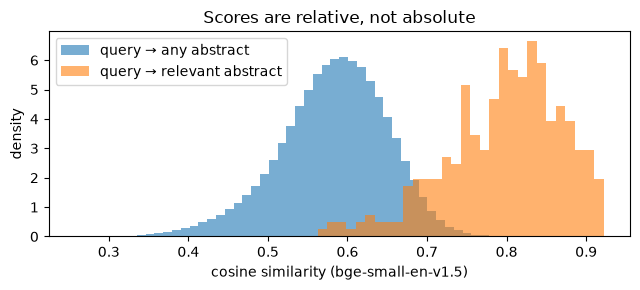

In [13]:
pair_idx = rng.choice(len(DOCS), size=(5000, 2))
doc_pair_cos = np.einsum("ij,ij->i", DOCS[pair_idx[:, 0]], DOCS[pair_idx[:, 1]])
bge_test_scores = EMB["BAAI/bge-small-en-v1.5"]["test"] @ DOCS.T
relevant_scores = np.array([bge_test_scores[r, doc_index[d]] for r, q in enumerate(test_qids) for d in test_rel[q]])
print(f"random abstract–abstract pairs: median cosine {np.median(doc_pair_cos):.3f}, min {doc_pair_cos.min():.3f}, share below 0: {(doc_pair_cos < 0).mean():.1%}")
print(f"query → random abstract       : median cosine {np.median(bge_test_scores):.3f}")
print(f"query → relevant abstract     : median cosine {np.median(relevant_scores):.3f} "
      f"(10th–90th percentile {np.percentile(relevant_scores, 10):.3f}–{np.percentile(relevant_scores, 90):.3f})")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(bge_test_scores.ravel(), bins=60, density=True, alpha=0.6, label="query → any abstract")
ax.hist(relevant_scores, bins=30, density=True, alpha=0.6, label="query → relevant abstract")
ax.set(xlabel="cosine similarity (bge-small-en-v1.5)", ylabel="density", title="Scores are relative, not absolute")
ax.legend()
plt.tight_layout()
plt.show()

Even unrelated abstracts get clearly positive cosines with this model — a known property of many embedding models (their vectors occupy a narrow cone). So a score is only meaningful **relative to other scores from the same model**: rank by it, but never hard-code a threshold like "0.5 = relevant". If you need a cut-off (e.g. "no good answer found" in RAG), tune it on labeled data, per model.

### ✍️ Your Turn

Return the indices of the **top 3** scores in `toy_scores`, highest first, using `np.argpartition` (then sort just those three).

In [14]:
toy_scores = np.array([0.1, 0.9, 0.3, 0.7, 0.5])
top3 = None  # TODO: your code here
check("top3", top3, [1, 3, 4], hint="idx = np.argpartition(-toy_scores, 3)[:3]; then idx[np.argsort(-toy_scores[idx])]")

⏳ top3: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
toy_scores = np.array([0.1, 0.9, 0.3, 0.7, 0.5])
idx = np.argpartition(-toy_scores, 3)[:3]          # the 3 best, in arbitrary order — O(n)
top3 = idx[np.argsort(-toy_scores[idx])].tolist()  # sort only those 3
check("top3", top3, [1, 3, 4])
```
</details>

> 💡 **Interview angle:** "Exact search over 10M vectors?" — brute force is O(N·d) per query: 10M × 384 dims is ~4 billion multiply-adds, ~1 s on one CPU core; fine offline, too slow online. Batch queries, use a GPU, or move to an approximate index (section 11).

## 8. Evaluating Retrieval: Recall@k, MRR, nDCG 🟡

"It looks good on three queries" is not evaluation. With relevance labels you can compute:

| Metric | Question it answers | Formula (per query, then averaged) |
|---|---|---|
| **Recall@k** | Did we find the relevant docs in the top k? (critical for RAG: the LLM only sees top k) | $\dfrac{|\text{relevant} \cap \text{top-}k|}{|\text{relevant}|}$ |
| **MRR@k** (mean reciprocal rank) | How high is the **first** relevant doc? | $\dfrac{1}{\text{rank of first relevant}}$ (0 if none in top k) |
| **nDCG@k** (normalized discounted cumulative gain) | Are relevant docs near the top, with graded credit? | $\dfrac{\sum_{i=1}^{k} \text{rel}_i / \log_2(i+1)}{\text{same sum for the ideal ranking}}$ |

nDCG gives full credit for a relevant doc at rank 1, ~63% at rank 2, 50% at rank 3, and so on, then divides by the best possible score so a perfect ranking = 1.0. It is BEIR's headline metric.

toy: recall@3 0.500 | MRR 0.500 | nDCG@5 0.651
bge-small on dev: {'nDCG@10': np.float64(0.7516), 'Recall@10': np.float64(0.8683), 'Recall@100': np.float64(0.9708), 'MRR@10': np.float64(0.7227)}


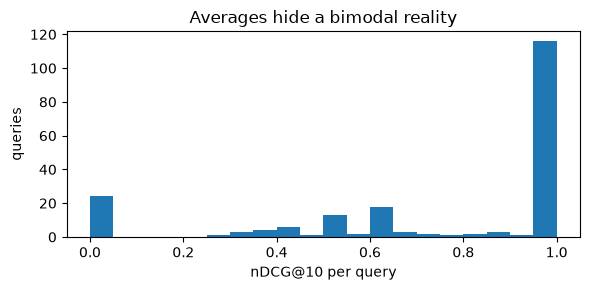

queries with nDCG@10 = 0 (nothing relevant in top 10): 12.0% | perfect (=1): 58.0%


In [15]:
def recall_at_k(ranked_ids, relevant, k):
    return len(relevant & set(ranked_ids[:k])) / len(relevant)


def mrr_at_k(ranked_ids, relevant, k=10):
    return next((1.0 / rank for rank, d in enumerate(ranked_ids[:k], 1) if d in relevant), 0.0)


def evaluate(rankings, qids, rel):
    return {"nDCG@10": np.mean([ndcg_at_k(r, rel[q], 10) for r, q in zip(rankings, qids)]),
            "Recall@10": np.mean([recall_at_k(r, rel[q], 10) for r, q in zip(rankings, qids)]),
            "Recall@100": np.mean([recall_at_k(r, rel[q], 100) for r, q in zip(rankings, qids)]),
            "MRR@10": np.mean([mrr_at_k(r, rel[q], 10) for r, q in zip(rankings, qids)])}


toy_ranking, toy_relevant = ["d3", "d1", "d7", "d4", "d9"], {"d1", "d4"}
print(f"toy: recall@3 {recall_at_k(toy_ranking, toy_relevant, 3):.3f} | MRR {mrr_at_k(toy_ranking, toy_relevant):.3f} | "
      f"nDCG@5 {ndcg_at_k(toy_ranking, toy_relevant, 5):.3f}")

dense_dev = dense_rankings(EMB["BAAI/bge-small-en-v1.5"]["dev"], DOCS)
dense_metrics = evaluate(dense_dev, dev_qids, train_rel)
print("bge-small on dev:", {k: round(v, 4) for k, v in dense_metrics.items()})

per_query = np.array([ndcg_at_k(r, train_rel[q]) for r, q in zip(dense_dev, dev_qids)])
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(per_query, bins=20)
ax.set(xlabel="nDCG@10 per query", ylabel="queries", title="Averages hide a bimodal reality")
plt.tight_layout()
plt.show()
print(f"queries with nDCG@10 = 0 (nothing relevant in top 10): {(per_query == 0).mean():.1%} | perfect (=1): {(per_query == 1).mean():.1%}")

Most queries are either solved or completely missed. When you improve a system, read the **failed queries** — that's where the next idea comes from.

### ✍️ Your Turn

Compute **MRR** over three queries. The first relevant document appears at rank 2 for query A, rank 1 for query B, and not at all in the top 10 for query C. Store the mean in `mrr_value`.

In [16]:
mrr_value = None  # TODO: your code here
check("mrr_value", mrr_value, 0.5, hint="Reciprocal ranks are 1/2, 1/1 and 0 — average them.")

⏳ mrr_value: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mrr_value = (1 / 2 + 1 / 1 + 0) / 3
check("mrr_value", mrr_value, 0.5)
```
</details>

> 💡 **Interview angle:** "Which retrieval metric for RAG?" — **Recall@k** for the retriever (did the answer-bearing chunk make it into the context window?), **nDCG/MRR** for ranking quality when order matters (rerankers, limited context). Build a labeled set of real queries first; without it every change is guesswork.

## 9. BM25 and Hybrid Search With Reciprocal Rank Fusion 🟡

**BM25** is the classic keyword ranking function behind Lucene, Elasticsearch, and OpenSearch. It is TF-IDF with two fixes: term frequency **saturates** (the 10th "protein" adds less than the 2nd), and long documents are **length-normalized**:

$$\text{BM25}(q, d) = \sum_{t \in q} \text{IDF}(t)\cdot\frac{f(t,d)\,(k_1+1)}{f(t,d) + k_1\left(1 - b + b\,\frac{|d|}{\text{avgdl}}\right)}, \qquad \text{IDF}(t) = \ln\!\left(1 + \frac{N - n_t + 0.5}{n_t + 0.5}\right)$$

with $k_1 \approx 1.2$–$1.5$ and $b = 0.75$. BM25 is excellent at **exact terms** — gene names, drug names, error codes, numbers — that embeddings can blur. Dense retrieval is better at **paraphrases**. They fail on different queries, so combining them usually helps.

We use `bm25s` (a fast NumPy/SciPy implementation) with an English **stemmer** (PyStemmer) and stopword removal.

In [17]:
stemmer = Stemmer.Stemmer("english")
t0 = time.perf_counter()
bm25 = bm25s.BM25()                                                      # defaults: k1=1.5, b=0.75, Lucene IDF
bm25.index(bm25s.tokenize(doc_texts, stopwords="en", stemmer=stemmer, show_progress=False), show_progress=False)
print(f"BM25 index built in {time.perf_counter() - t0:.2f}s")


def bm25_rankings(query_texts, k=100):
    ids, _ = bm25.retrieve(bm25s.tokenize(query_texts, stopwords="en", stemmer=stemmer, show_progress=False), k=k, show_progress=False)
    return [[doc_ids[i] for i in row] for row in ids]


bm25_dev = bm25_rankings(dev_queries)
bm25_metrics = evaluate(bm25_dev, dev_qids, train_rel)
bm25_per_query = np.array([ndcg_at_k(r, train_rel[q]) for r, q in zip(bm25_dev, dev_qids)])
print("BM25 on dev :", {k: round(v, 4) for k, v in bm25_metrics.items()})
print("dense on dev:", {k: round(v, 4) for k, v in dense_metrics.items()})
print(f"per query: BM25 better on {(bm25_per_query > per_query).sum()}, dense better on {(per_query > bm25_per_query).sum()}, "
      f"tied on {(per_query == bm25_per_query).sum()} of {len(dev_qids)} queries")

BM25 index built in 0.59s
BM25 on dev : {'nDCG@10': np.float64(0.7048), 'Recall@10': np.float64(0.8462), 'Recall@100': np.float64(0.9308), 'MRR@10': np.float64(0.6707)}
dense on dev: {'nDCG@10': np.float64(0.7516), 'Recall@10': np.float64(0.8683), 'Recall@100': np.float64(0.9708), 'MRR@10': np.float64(0.7227)}
per query: BM25 better on 30, dense better on 52, tied on 118 of 200 queries


**Reciprocal Rank Fusion (RRF)** combines ranked lists using only **ranks**, not scores — so you never have to calibrate BM25 scores (0–40) against cosines (0–1):

$$\text{RRF}(d) = \sum_{\text{lists } L} \frac{1}{k + \text{rank}_L(d)}, \qquad k = 60 \text{ (the value from the original paper)}$$

A document ranked highly by *either* retriever rises; one ranked highly by *both* rises most.

In [18]:
def rrf(ranking_lists, k=60, top_n=100):
    fused = []
    for per_query_lists in zip(*ranking_lists):
        scores = {}
        for ranking in per_query_lists:
            for rank, d in enumerate(ranking, 1):
                scores[d] = scores.get(d, 0.0) + 1.0 / (k + rank)
        fused.append(sorted(scores, key=scores.get, reverse=True)[:top_n])
    return fused


hybrid_dev = rrf([bm25_dev, dense_dev])
hybrid_metrics = evaluate(hybrid_dev, dev_qids, train_rel)
comparison9 = pd.DataFrame({"BM25": bm25_metrics, "dense (bge-small)": dense_metrics, "hybrid (RRF)": hybrid_metrics}).T
display(comparison9.round(4))
print(f"hybrid vs best single retriever: {hybrid_metrics['nDCG@10'] - max(bm25_metrics['nDCG@10'], dense_metrics['nDCG@10']):+.4f} nDCG@10 on dev")

,nDCG@10,Recall@10,Recall@100,MRR@10
BM25,0.7048,0.8462,0.9308,0.6707
dense (bge-small),0.7516,0.8683,0.9708,0.7227
hybrid (RRF),0.7600,0.8758,0.9783,0.7352


hybrid vs best single retriever: +0.0084 nDCG@10 on dev


### ✍️ Your Turn

Compute BM25's Lucene-style IDF for a term that appears in `n_t = 12` of `N = 5183` documents. Store it in `bm25_idf`.

In [19]:
bm25_idf = None  # TODO: your code here
check("bm25_idf", bm25_idf, 6.027603593723855, hint="math.log(1 + (N - n_t + 0.5) / (n_t + 0.5))")

⏳ bm25_idf: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
N, n_t = 5183, 12
bm25_idf = math.log(1 + (N - n_t + 0.5) / (n_t + 0.5))
check("bm25_idf", bm25_idf, 6.027603593723855)
```
The `1 +` inside the log keeps IDF positive even for terms in more than half the documents (the original Robertson formula can go negative).
</details>

> 💡 **Interview angle:** "Why hybrid search, and why RRF instead of adding scores?" — BM25 and dense models fail on different queries (exact identifiers vs paraphrases). Their scores live on different scales and shift per query, so a weighted sum needs normalization and tuning; RRF uses ranks only, has one robust parameter, and is the default in Elasticsearch, OpenSearch, and most vector databases.

## 10. Reranking With a Cross-Encoder 🟡

**Retrieve-then-rerank:** take the top candidates from the first stage (here: the hybrid top 30) and reorder them with the cross-encoder from section 5. Two ways to use the reranker's output:

- **replace** — sort the candidates by cross-encoder score alone;
- **fuse** — RRF the reranked list with the first-stage list, so a reranker mistake can't bury a document both retrievers liked.

Rerankers are often presented as a free win. Let's **measure** on the dev queries, including latency.

In [20]:
RERANK_DEPTH = 30
doc_text_by_id = dict(zip(doc_ids, doc_texts))


def rerank(query_texts, first_stage, depth=RERANK_DEPTH):
    reranked = []
    t0 = time.perf_counter()
    for q, ranking in zip(query_texts, first_stage):
        head = ranking[:depth]
        ce = cross_encoder.predict([(q, doc_text_by_id[d]) for d in head], batch_size=64)
        reranked.append([head[i] for i in np.argsort(-ce)] + ranking[depth:])
    return reranked, (time.perf_counter() - t0) * 1000 / len(query_texts)


rerank_dev, rerank_ms = rerank(dev_queries, hybrid_dev)
fused_dev = rrf([hybrid_dev, rerank_dev])
rerank_table = pd.DataFrame({"hybrid (no rerank)": evaluate(hybrid_dev, dev_qids, train_rel),
                             "hybrid + rerank (replace)": evaluate(rerank_dev, dev_qids, train_rel),
                             "hybrid + rerank (fuse)": evaluate(fused_dev, dev_qids, train_rel)}).T
rerank_table["added latency (ms/query)"] = [0.0, rerank_ms, rerank_ms]
display(rerank_table.round(4))

gain = rerank_table.loc["hybrid + rerank (replace)", "nDCG@10"] - rerank_table.loc["hybrid (no rerank)", "nDCG@10"]
verdict = "helps" if gain > 0.005 else ("hurts" if gain < -0.005 else "makes no real difference")
print(f"On dev, replacing the ranking with ms-marco-MiniLM-L6-v2 {verdict} ({gain:+.4f} nDCG@10) and costs ~{rerank_ms:.0f} ms per query.")

,nDCG@10,Recall@10,Recall@100,MRR@10,added latency (ms/query)
hybrid (no rerank),0.7600,0.8758,0.9783,0.7352,0.000
hybrid + rerank (replace),0.7500,0.8842,0.9783,0.7188,229.118
hybrid + rerank (fuse),0.7729,0.8958,0.9783,0.7434,229.118


On dev, replacing the ranking with ms-marco-MiniLM-L6-v2 hurts (-0.0101 nDCG@10) and costs ~229 ms per query.


Whatever the sign on your run, the lesson stands: this cross-encoder was trained on **MS MARCO** (web search questions), while SciFact queries are **scientific claims** matched to abstracts — a domain shift. A strong hybrid first stage also leaves less room to improve. Evaluate rerankers on your own labeled queries; consider a domain-appropriate or larger reranker, fusing instead of replacing, or fine-tuning the reranker. The mini project makes the final call on dev and reports test once.

> 💡 **Interview angle:** "Your reranker made results worse — why?" — domain mismatch with its training data, truncation of long passages (512 tokens), too shallow/deep candidate lists, or a first stage already better than the reranker on that domain. Fix by evaluating on in-domain labels, fusing with first-stage ranks, or fine-tuning the cross-encoder on your data.

## 11. Approximate Nearest Neighbour Search With FAISS 🔴

Brute-force search compares the query with **every** vector. **Approximate nearest neighbour (ANN)** indexes trade a little recall for a lot of speed. **FAISS** (Facebook AI Similarity Search) provides the classic ones:

| Index | Idea | Knobs | Trade-off |
|---|---|---|---|
| `IndexFlatIP` / `IndexFlatL2` | brute force, exact | — | 100% recall, O(N) per query |
| `IndexHNSWFlat` | **H**ierarchical **N**avigable **S**mall **W**orld graph: greedy walk from a sparse top layer down to dense lower layers | `M` (links per node), `efConstruction`, `efSearch` (candidate list size at query time) | very fast and high recall; extra memory for links; slow-ish to build |
| `IndexIVFFlat` | **I**nverted **F**ile: k-means splits vectors into `nlist` cells; a query only scans the `nprobe` nearest cells | `nlist`, `nprobe` | fast build, low memory overhead; recall depends on `nprobe`; needs training |
| `IndexIVFPQ` | IVF + **P**roduct **Q**uantization (compress each vector to a few bytes) | + `m`, `nbits` | billions of vectors in RAM, lower recall |

SciFact's 5k documents are too small to show any speed difference, so we use a bigger **real** corpus: 200,000 questions from BEIR Quora, embedded with the fast static model (truncated to 256 dimensions — section 12 explains why that's allowed).

In [21]:
quora = load_dataset("BeIR/quora", "corpus", split="corpus")
quora_queries = load_dataset("BeIR/quora", "queries", split="queries")
ann_rng = np.random.default_rng(SEED)
quora_texts = quora["text"]
base_texts = [quora_texts[int(i)] for i in ann_rng.choice(len(quora), size=200_000, replace=False)]
ann_query_texts = [quora_queries["text"][int(i)] for i in ann_rng.choice(len(quora_queries), size=1000, replace=False)]

t0 = time.perf_counter()
ann_base = static_model.encode_document(base_texts, batch_size=4096, truncate_dim=256, convert_to_numpy=True)
ann_base /= np.linalg.norm(ann_base, axis=1, keepdims=True)
ann_queries = static_model.encode_query(ann_query_texts, truncate_dim=256, convert_to_numpy=True)
ann_queries /= np.linalg.norm(ann_queries, axis=1, keepdims=True)
print(f"embedded {len(base_texts):,} Quora questions in {time.perf_counter() - t0:.1f}s on CPU → {ann_base.shape}, {ann_base.nbytes / 1e6:.0f} MB")

np.save(OUTPUT_DIR / "ann_base.npy", ann_base.astype(np.float32))
np.save(OUTPUT_DIR / "ann_queries.npy", ann_queries.astype(np.float32))
np.save(OUTPUT_DIR / "scifact_docs.npy", DOCS.astype(np.float32))
np.save(OUTPUT_DIR / "scifact_test_queries.npy", EMB["BAAI/bge-small-en-v1.5"]["test"].astype(np.float32))
del quora, quora_texts, base_texts

embedded 200,000 Quora questions in 5.9s on CPU → (200000, 256), 205 MB


The FAISS code below is a normal Python script. We write it to `_outputs/faiss_benchmark.py` and run it with the same interpreter in a **separate process** (see the Setup note on OpenMP). On Linux or Colab you could paste the same code straight into a cell.

It measures:
- a sanity check that `IndexFlatIP` returns exactly the NumPy top-10 on SciFact,
- build time (using all CPU cores), memory, **per-query latency on one thread** (one request = one core, like a busy web server), and **recall@10 relative to exact search** for Flat, HNSW (several `efSearch`), and IVF (several `nprobe`).

In [22]:
FAISS_SCRIPT = r'''
import json, os, sys, time
import numpy as np
import faiss                                     # imported only here, never together with torch

def build_threads():
    faiss.omp_set_num_threads(max(1, os.cpu_count() or 1))

def query_threads():
    faiss.omp_set_num_threads(1)

build_threads()
out_dir = sys.argv[1]
base = np.load(f"{out_dir}/ann_base.npy")
queries = np.load(f"{out_dir}/ann_queries.npy")
k, d = 10, base.shape[1]
results = {"faiss_version": faiss.__version__, "n_vectors": int(base.shape[0]), "dim": int(d)}

# 1) sanity check on SciFact: FAISS exact search == NumPy exact search
sf_docs, sf_q = np.load(f"{out_dir}/scifact_docs.npy"), np.load(f"{out_dir}/scifact_test_queries.npy")
flat_sf = faiss.IndexFlatIP(sf_docs.shape[1]); flat_sf.add(sf_docs)
_, faiss_ids = flat_sf.search(sf_q, k)
results["scifact_faiss_ids"] = faiss_ids.tolist()

def per_query_latency(index, n=300):
    query_threads()
    for i in range(20):                          # untimed warm-up: first searches pay one-off costs
        index.search(queries[-1 - i:len(queries) - i], k)
    start = time.perf_counter()
    ids = np.vstack([index.search(queries[i:i + 1], k)[1] for i in range(n)])
    elapsed = (time.perf_counter() - start) * 1000 / n
    build_threads()
    return ids, elapsed

def index_mb(index):
    return faiss.serialize_index(index).nbytes / 1e6

flat = faiss.IndexFlatIP(d)
t = time.perf_counter(); flat.add(base); flat_build = time.perf_counter() - t
truth, flat_ms = per_query_latency(flat)
rows = [{"index": "Flat (exact)", "setting": "-", "build_s": flat_build, "ms_per_query": flat_ms, "recall@10": 1.0, "memory_MB": index_mb(flat)}]

def recall(ids):
    return float(np.mean([len(set(a) & set(b)) / k for a, b in zip(ids, truth)]))

hnsw = faiss.IndexHNSWFlat(d, 32, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = 64
t = time.perf_counter(); hnsw.add(base); hnsw_build = time.perf_counter() - t
hnsw_mb = index_mb(hnsw)
for ef in [16, 32, 64, 128, 256]:
    hnsw.hnsw.efSearch = ef
    ids, ms = per_query_latency(hnsw)
    rows.append({"index": "HNSW (M=32)", "setting": f"efSearch={ef}", "build_s": hnsw_build, "ms_per_query": ms, "recall@10": recall(ids), "memory_MB": hnsw_mb})

quantizer = faiss.IndexFlatIP(d)
ivf = faiss.IndexIVFFlat(quantizer, d, 1024, faiss.METRIC_INNER_PRODUCT)
t = time.perf_counter()
ivf.train(base[np.random.default_rng(0).choice(len(base), 50_000, replace=False)])
ivf.add(base)
ivf_build = time.perf_counter() - t
ivf_mb = index_mb(ivf)
for nprobe in [1, 4, 16, 64]:
    ivf.nprobe = nprobe
    ids, ms = per_query_latency(ivf)
    rows.append({"index": "IVF (nlist=1024)", "setting": f"nprobe={nprobe}", "build_s": ivf_build, "ms_per_query": ms, "recall@10": recall(ids), "memory_MB": ivf_mb})

results["rows"] = rows
print(json.dumps(results))
'''

script_path = OUTPUT_DIR / "faiss_benchmark.py"
script_path.write_text(FAISS_SCRIPT)
t0 = time.perf_counter()
proc = subprocess.run([sys.executable, str(script_path), str(OUTPUT_DIR)], capture_output=True, text=True)
if proc.returncode != 0:
    print(f"⚠️ FAISS benchmark failed (exit code {proc.returncode}). stderr:\n{proc.stderr[-2000:]}")
    faiss_results = None
else:
    faiss_results = json.loads(proc.stdout)
    print(f"FAISS {faiss_results['faiss_version']} benchmark finished in {time.perf_counter() - t0:.0f}s "
          f"on {faiss_results['n_vectors']:,} × {faiss_results['dim']} vectors")

FAISS 1.15.0 benchmark finished in 14s on 200,000 × 256 vectors


SciFact sanity check — FAISS IndexFlatIP top-10 identical to NumPy for 100.0% of positions


,index,setting,build_s,ms_per_query,recall@10,memory_MB,speed-up vs Flat
0,Flat (exact),-,0.430,7.631,1.000,204.800,1.000
1,HNSW (M=32),efSearch=16,6.839,0.151,0.834,259.228,50.542
2,HNSW (M=32),efSearch=32,6.839,0.084,0.880,259.228,90.792
3,HNSW (M=32),efSearch=64,6.839,0.141,0.909,259.228,54.199
4,HNSW (M=32),efSearch=128,6.839,0.375,0.928,259.228,20.323
5,HNSW (M=32),efSearch=256,6.839,0.642,0.948,259.228,11.880
6,IVF (nlist=1024),nprobe=1,1.913,0.102,0.549,207.457,74.701
7,IVF (nlist=1024),nprobe=4,1.913,0.114,0.742,207.457,66.778
8,IVF (nlist=1024),nprobe=16,1.913,0.173,0.830,207.457,44.003
9,IVF (nlist=1024),nprobe=64,1.913,0.532,0.899,207.457,14.333


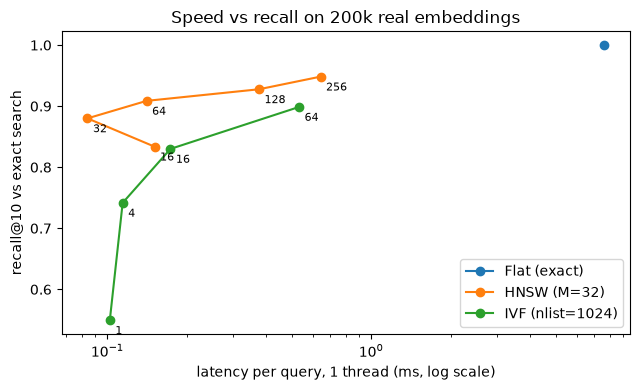

Fastest approximate index with recall@10 ≥ 0.90: HNSW (M=32) efSearch=64 — 0.141 ms/query (54× faster than exact search), 259 MB vs 205 MB for Flat
build time: Flat 0.4s | HNSW 6.8s | IVF 1.9s (all cores)


In [23]:
if faiss_results is not None:
    numpy_top10 = np.argsort(-(EMB["BAAI/bge-small-en-v1.5"]["test"] @ DOCS.T), axis=1)[:, :10]
    agree = (np.array(faiss_results["scifact_faiss_ids"]) == numpy_top10).mean()
    print(f"SciFact sanity check — FAISS IndexFlatIP top-10 identical to NumPy for {agree:.1%} of positions")

    ann_table = pd.DataFrame(faiss_results["rows"])
    ann_table["speed-up vs Flat"] = ann_table.loc[0, "ms_per_query"] / ann_table["ms_per_query"]
    display(ann_table.round(3))

    fig, ax = plt.subplots(figsize=(6.5, 4))
    for name, group in ann_table.groupby("index", sort=False):
        ax.plot(group["ms_per_query"], group["recall@10"], marker="o", label=name)
        for _, r in group.iterrows():
            if r["setting"] != "-":
                ax.annotate(r["setting"].split("=")[1], (r["ms_per_query"], r["recall@10"]), textcoords="offset points", xytext=(4, -10), fontsize=8)
    ax.set(xscale="log", xlabel="latency per query, 1 thread (ms, log scale)", ylabel="recall@10 vs exact search",
           title="Speed vs recall on 200k real embeddings")
    ax.legend()
    plt.tight_layout()
    plt.show()

    approximate = ann_table[ann_table["index"] != "Flat (exact)"]
    for target in (0.95, 0.90):
        ok = approximate[approximate["recall@10"] >= target].sort_values("ms_per_query")
        if len(ok):
            best = ok.iloc[0]
            print(f"Fastest approximate index with recall@10 ≥ {target:.2f}: {best['index']} {best['setting']} — "
                  f"{best['ms_per_query']:.3f} ms/query ({best['speed-up vs Flat']:.0f}× faster than exact search), "
                  f"{best['memory_MB']:.0f} MB vs {ann_table.loc[0, 'memory_MB']:.0f} MB for Flat")
            break
    else:
        print("No approximate configuration reached recall@10 ≥ 0.90 here — raise efSearch / nprobe.")
    hnsw_build = ann_table.loc[ann_table["index"].str.startswith("HNSW"), "build_s"].iloc[0]
    ivf_build = ann_table.loc[ann_table["index"].str.startswith("IVF"), "build_s"].iloc[0]
    print(f"build time: Flat {ann_table.loc[0, 'build_s']:.1f}s | HNSW {hnsw_build:.1f}s | IVF {ivf_build:.1f}s (all cores)")

Read the table like an engineer:
- **HNSW** usually gives the best recall-per-millisecond, but costs extra memory for its graph links and takes longest to build; vectors can't easily be deleted.
- **IVF** builds fast with little memory overhead; recall climbs with `nprobe` (and so does latency). Combine with PQ when memory is the constraint.
- **Flat** is exact and simplest — perfectly fine up to roughly a few hundred thousand vectors, especially with batching or a GPU.
- Latencies below ~1 ms are noisy on a laptop doing other work, so neighbouring settings can swap places between runs; trust the overall trend (and the recall column, which is deterministic), and benchmark on your production hardware.

> 💡 **Interview angle:** "How does HNSW work and what do its parameters do?" — a multi-layer proximity graph: search starts at the sparse top layer, greedily moves to closer neighbours, and descends; `M` controls links per node (memory, recall), `efConstruction` build quality, `efSearch` the query-time candidate list (recall vs latency). Be ready to compare with IVF (`nlist`, `nprobe`) and to mention PQ for memory.

## 12. Quantization and Matryoshka Embeddings 🟡

Embedding memory = **vectors × dimensions × bytes per number**. Two ways to shrink it:

1. **Quantization** — store fewer bits per dimension:
   - **int8 (scalar):** map each dimension's range to −128…127 → 4× smaller.
   - **binary:** keep only the sign bit of each dimension → 32× smaller; compare with **Hamming distance** (count differing bits), which CPUs do extremely fast. A common trick is **rescoring**: retrieve extra candidates with binary vectors, then re-score them with higher-precision vectors.
2. **Matryoshka Representation Learning (MRL)** — train the model so the **first** dimensions carry the most information (like nested Russian dolls). You can then **truncate** vectors to 256, 128, or 64 dimensions and re-normalize. Models *not* trained this way usually lose more quality for the same compression — but measure it.

### Quantization on SciFact (bge-small, dev queries)

In [24]:
from sentence_transformers.util import quantize_embeddings

dev_q = EMB["BAAI/bge-small-en-v1.5"]["dev"]
ranges = np.vstack([DOCS.min(axis=0), DOCS.max(axis=0)])                       # calibration ranges from the corpus
docs_int8 = quantize_embeddings(DOCS, precision="int8", ranges=ranges)
q_int8 = quantize_embeddings(dev_q, precision="int8", ranges=ranges)
docs_bin = quantize_embeddings(DOCS, precision="ubinary")                      # 384 bits → 48 bytes per doc
q_bin = quantize_embeddings(dev_q, precision="ubinary")
print("dtypes/shapes:", docs_int8.dtype, docs_int8.shape, "|", docs_bin.dtype, docs_bin.shape)


def rankings_from_scores(score_matrix, k=100):
    top = np.argsort(-score_matrix, axis=1)[:, :k]
    return [[doc_ids[i] for i in row] for row in top]


def hamming_scores(q_codes, d_codes, chunk=50):
    out = []
    for s in range(0, len(q_codes), chunk):
        xor = np.bitwise_xor(q_codes[s:s + chunk, None, :], d_codes[None, :, :])
        out.append(-np.bitwise_count(xor).sum(axis=-1, dtype=np.int32))     # fewer differing bits = more similar
    return np.vstack(out)


float_rank = rankings_from_scores(dev_q @ DOCS.T)
int8_rank = rankings_from_scores(q_int8.astype(np.int32) @ docs_int8.astype(np.int32).T)
bin_scores = hamming_scores(q_bin, docs_bin)
bin_rank = rankings_from_scores(bin_scores.astype(np.float32))

rescored = []                                                                  # binary top-100 → rescore with float query · int8 docs
for qi, row in enumerate(np.argsort(-bin_scores, axis=1, kind="stable")[:, :100]):
    s = docs_int8[row].astype(np.float32) @ dev_q[qi]
    rescored.append([doc_ids[row[j]] for j in np.argsort(-s)])

n_docs, dim = DOCS.shape
quant_rows = []
for name, ranking, bytes_per_vec in [("float32", float_rank, dim * 4), ("int8", int8_rank, dim),
                                     ("binary (Hamming)", bin_rank, math.ceil(dim / 8)),
                                     ("binary + int8 rescoring", rescored, math.ceil(dim / 8))]:
    quant_rows.append({"precision": name, "bytes / vector": bytes_per_vec, "MB for 10M vectors": bytes_per_vec * 10_000_000 / 1e6,
                       "dev nDCG@10": mean_ndcg(ranking, dev_qids, train_rel)})
quant_table = pd.DataFrame(quant_rows).set_index("precision")
quant_table["quality retained"] = quant_table["dev nDCG@10"] / quant_table.loc["float32", "dev nDCG@10"]
display(quant_table.round(3))
print("(the rescoring row still needs int8 vectors for the 100 candidates — typically kept on disk, not in RAM)")

dtypes/shapes: int8 (5183, 384) | uint8 (5183, 48)


,bytes / vector,MB for 10M vectors,dev nDCG@10,quality retained
precision,,,,
float32,1536,15360.0,0.752,1.000
int8,384,3840.0,0.728,0.968
binary (Hamming),48,480.0,0.687,0.914
binary + int8 rescoring,48,480.0,0.746,0.992


(the rescoring row still needs int8 vectors for the 100 candidates — typically kept on disk, not in RAM)


### Matryoshka truncation: MRL-trained vs not

The two models have different sizes (1024 vs 384 dimensions), so we compare them at the same **compression factor**: keep 1/2, 1/4, 1/8, 1/16 of each model's dimensions, re-normalize, and measure how much of its full-size dev nDCG@10 survives.

,static-mrl dims,static-mrl nDCG@10,static-mrl retained,bge-small dims,bge-small nDCG@10,bge-small retained
dims kept,,,,,,
all,1024,0.625,1.000,384,0.752,1.000
1/2,512,0.607,0.972,192,0.740,0.985
1/4,256,0.579,0.926,96,0.641,0.853
1/8,128,0.558,0.893,48,0.522,0.694
1/16,64,0.469,0.751,24,0.293,0.389


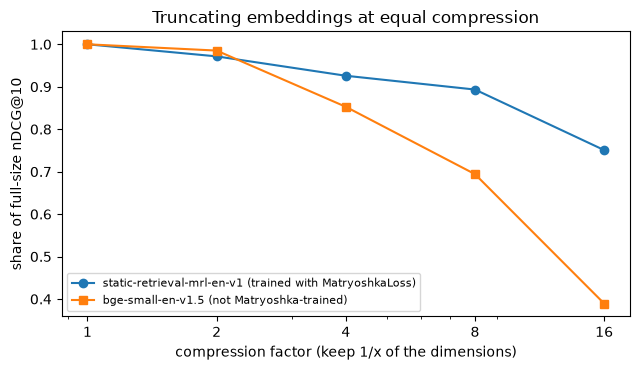

keep 1/4: static-mrl (256-d) retains 92.6%, bge-small (96-d) retains 85.3% → static-mrl degrades more gracefully
keep 1/8: static-mrl (128-d) retains 89.3%, bge-small (48-d) retains 69.4% → static-mrl degrades more gracefully
absolute quality still matters: bge-small at 96 dims scores 0.641 vs static-mrl at 256 dims 0.579


In [25]:
def truncated_ndcg(doc_matrix, query_matrix, dims):
    scores = []
    for d in dims:
        D = doc_matrix[:, :d] / np.linalg.norm(doc_matrix[:, :d], axis=1, keepdims=True)
        Q = query_matrix[:, :d] / np.linalg.norm(query_matrix[:, :d], axis=1, keepdims=True)
        scores.append(mean_ndcg(rankings_from_scores(Q @ D.T), dev_qids, train_rel))
    return np.array(scores)


static_docs = EMB["sentence-transformers/static-retrieval-mrl-en-v1"]["docs"]
static_dev = EMB["sentence-transformers/static-retrieval-mrl-en-v1"]["dev"]
fractions = [1, 2, 4, 8, 16]                                                   # keep 1/f of the dimensions
dims_static = [1024 // f for f in fractions]                                   # 1024 … 64
dims_bge = [384 // f for f in fractions]                                       # 384 … 24
mrl_scores = truncated_ndcg(static_docs, static_dev, dims_static)
bge_scores = truncated_ndcg(DOCS, dev_q, dims_bge)

trunc_table = pd.DataFrame({
    "dims kept": [f"1/{f}" if f > 1 else "all" for f in fractions],
    "static-mrl dims": dims_static, "static-mrl nDCG@10": mrl_scores, "static-mrl retained": mrl_scores / mrl_scores[0],
    "bge-small dims": dims_bge, "bge-small nDCG@10": bge_scores, "bge-small retained": bge_scores / bge_scores[0],
}).set_index("dims kept")
display(trunc_table.round(3))

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(fractions, trunc_table["static-mrl retained"], marker="o", label="static-retrieval-mrl-en-v1 (trained with MatryoshkaLoss)")
ax.plot(fractions, trunc_table["bge-small retained"], marker="s", label="bge-small-en-v1.5 (not Matryoshka-trained)")
ax.set(xscale="log", xlabel="compression factor (keep 1/x of the dimensions)", ylabel="share of full-size nDCG@10",
       title="Truncating embeddings at equal compression")
ax.set_xticks(fractions, [str(f) for f in fractions])
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for f in (4, 8):
    row = trunc_table.loc[f"1/{f}"]
    better = "static-mrl" if row["static-mrl retained"] > row["bge-small retained"] else "bge-small"
    print(f"keep 1/{f}: static-mrl ({int(row['static-mrl dims'])}-d) retains {row['static-mrl retained']:.1%}, "
          f"bge-small ({int(row['bge-small dims'])}-d) retains {row['bge-small retained']:.1%} → {better} degrades more gracefully")
row4 = trunc_table.loc["1/4"]
print(f"absolute quality still matters: bge-small at {int(row4['bge-small dims'])} dims scores {row4['bge-small nDCG@10']:.3f} "
      f"vs static-mrl at {int(row4['static-mrl dims'])} dims {row4['static-mrl nDCG@10']:.3f}")

Caveat: these two models differ in more than Matryoshka training (a static lookup table vs a transformer), so treat this as an illustration. The clean experiment — the same model trained with and without `MatryoshkaLoss` — is in the Matryoshka Representation Learning paper. Also note that a strong non-MRL model truncated a little can still beat a weaker MRL model at the same byte budget: compare **absolute** scores at your memory budget, not just retention.

Quantization and truncation **stack**: a 256-dim binary vector is 32 bytes. In production you'd often keep a compact index in RAM for first-stage search and full-precision vectors on disk for rescoring.

### ✍️ Your Turn

Two binary codes are stored as `uint8` bytes. Compute their **Hamming distance** (the number of bits that differ). Store an `int` in `hamming`.

In [26]:
code_a = np.array([0b10110000, 0b11110000], dtype=np.uint8)
code_b = np.array([0b10011000, 0b11110001], dtype=np.uint8)
hamming = None  # TODO: your code here
check("hamming", hamming, 3, hint="XOR marks the differing bits; np.bitwise_count counts them: int(np.bitwise_count(code_a ^ code_b).sum())")

⏳ hamming: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
code_a = np.array([0b10110000, 0b11110000], dtype=np.uint8)
code_b = np.array([0b10011000, 0b11110001], dtype=np.uint8)
hamming = int(np.bitwise_count(code_a ^ code_b).sum())
check("hamming", hamming, 3)
```
Byte 1: `10110000 ^ 10011000 = 00101000` (2 bits); byte 2: `11110000 ^ 11110001 = 00000001` (1 bit).
</details>

> 💡 **Interview angle:** "Your vector index doesn't fit in RAM — options?" — lower precision (int8 4×, binary 32× with rescoring), Matryoshka truncation if the model supports it, product quantization (IVF-PQ), a smaller-dimension model, or disk-based indexes (DiskANN-style); always report the recall/nDCG you lose on a labeled set.

## 13. Clustering and Visualizing Embeddings 🟢

Embeddings are useful without any query: **cluster** them to discover themes, deduplicate, or explore a dataset. We embed 1,200 posts from six newsgroups (the dataset from the previous notebook), cluster with k-means, and compare the clusters with the true groups using the **Adjusted Rand Index (ARI)** — 1.0 = identical grouping, 0 = random.

ARI — k-means on MiniLM embeddings: 0.716 | k-means on TF-IDF: 0.293 → embeddings recover the newsgroups better


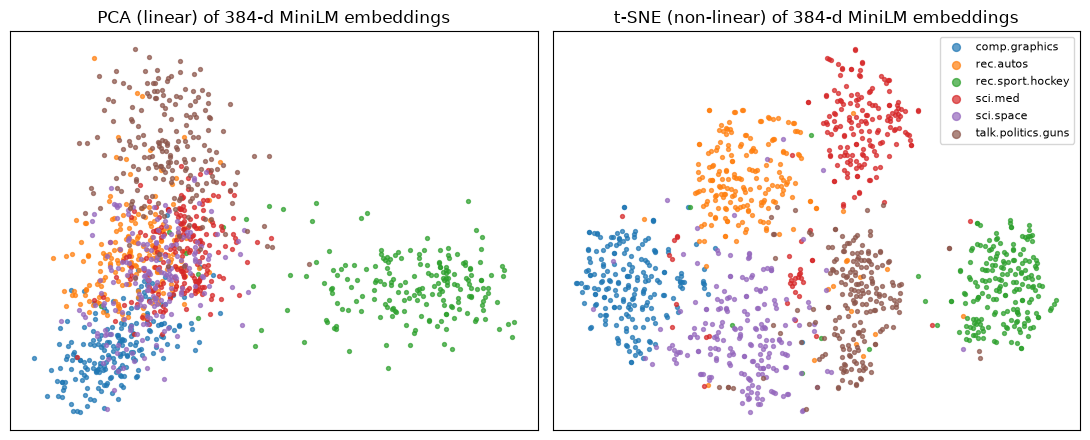

In [27]:
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score

groups = ["comp.graphics", "rec.autos", "rec.sport.hockey", "sci.med", "sci.space", "talk.politics.guns"]
news = fetch_20newsgroups(subset="train", categories=groups, remove=("headers", "footers", "quotes"), random_state=SEED)
keep = [i for i, d in enumerate(news.data) if len(d.split()) >= 20]
picked = np.concatenate([ann_rng.choice([i for i in keep if news.target[i] == c], 200, replace=False) for c in range(len(groups))])
news_texts = [news.data[i][:2000] for i in picked]
news_labels = news.target[picked]

news_emb = minilm.encode(news_texts, batch_size=64, normalize_embeddings=True)
km_dense = KMeans(n_clusters=len(groups), n_init=10, random_state=SEED).fit(news_emb)
tfidf_matrix = TfidfVectorizer(min_df=2, stop_words="english", sublinear_tf=True).fit_transform(news_texts)
km_tfidf = KMeans(n_clusters=len(groups), n_init=10, random_state=SEED).fit(tfidf_matrix)
ari_dense = adjusted_rand_score(news_labels, km_dense.labels_)
ari_tfidf = adjusted_rand_score(news_labels, km_tfidf.labels_)
print(f"ARI — k-means on MiniLM embeddings: {ari_dense:.3f} | k-means on TF-IDF: {ari_tfidf:.3f} "
      f"→ {'embeddings' if ari_dense > ari_tfidf else 'TF-IDF'} recover the newsgroups better")

coords_pca = PCA(n_components=2, random_state=SEED).fit_transform(news_emb)
coords_tsne = TSNE(n_components=2, init="pca", perplexity=30, random_state=SEED).fit_transform(news_emb)
cmap = plt.colormaps["tab10"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, coords, title in [(axes[0], coords_pca, "PCA (linear)"), (axes[1], coords_tsne, "t-SNE (non-linear)")]:
    for c, name in enumerate(groups):
        m = news_labels == c
        ax.scatter(coords[m, 0], coords[m, 1], s=8, color=cmap(c), label=name, alpha=0.7)
    ax.set_title(f"{title} of 384-d MiniLM embeddings")
    ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(markerscale=2, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

PCA keeps global linear structure; t-SNE keeps local neighbourhoods, so it separates clusters visually but **distances between clusters and cluster sizes in a t-SNE plot are not meaningful**. Use plots to explore, and metrics like ARI to conclude.

> 💡 **Interview angle:** "How would you find duplicate support tickets?" — embed, then for each item find neighbours above a similarity threshold (ANN index for scale), tune the threshold on a labeled sample for precision/recall, and use clustering (k-means, HDBSCAN, or `util.community_detection`) to group near-duplicates.

## 14. Fine-Tuning an Embedding Model 🔴

Off-the-shelf models are trained on general web data. If your queries use domain language (scientific claims, legal clauses, product codes), a little fine-tuning on **(query, relevant passage)** pairs often gives a big jump.

**`MultipleNegativesRankingLoss` (MNRL)** — a contrastive loss with **in-batch negatives**. For a batch of pairs $(q_i, p_i)$, every *other* passage $p_j$ in the batch acts as a negative for $q_i$:

$$L = -\frac{1}{B}\sum_{i=1}^{B} \log \frac{\exp(s\cdot\cos(q_i, p_i))}{\sum_{j=1}^{B}\exp(s\cdot\cos(q_i, p_j))}, \qquad s = 20 \text{ (scale)}$$

It is just cross-entropy where the "correct class" of row $i$ is column $i$ of the similarity matrix. Bigger batches = more negatives = usually better. `BatchSamplers.NO_DUPLICATES` prevents the same passage from appearing twice in a batch (which would create false negatives).

We fine-tune **`all-MiniLM-L6-v2`** (the weakest model in section 6, so there's room to improve) on SciFact's **training** queries that are *not* in our dev set, then evaluate before and after on **dev** and **test** — neither set is used for training.

In [28]:
from datasets import Dataset
from sentence_transformers import SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.base.sampler import BatchSamplers
from sentence_transformers.sentence_transformer.losses import MultipleNegativesRankingLoss

train_pairs = [(qid_to_text[q], doc_text_by_id[d]) for q in fit_qids for d in sorted(train_rel[q])]
train_dataset = Dataset.from_dict({"anchor": [a for a, _ in train_pairs], "positive": [p for _, p in train_pairs]}).shuffle(seed=SEED)
print(f"training pairs: {len(train_dataset)} from {len(fit_qids)} queries | columns: {train_dataset.column_names}")
print("example:", {k: v[:80] + "…" for k, v in train_dataset[0].items()})

minilm_before = {"dev": evaluate(dense_rankings(EMB["sentence-transformers/all-MiniLM-L6-v2"]["dev"], EMB["sentence-transformers/all-MiniLM-L6-v2"]["docs"]), dev_qids, train_rel),
                 "test": evaluate(dense_rankings(EMB["sentence-transformers/all-MiniLM-L6-v2"]["test"], EMB["sentence-transformers/all-MiniLM-L6-v2"]["docs"]), test_qids, test_rel)}

finetune_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)
training_args = SentenceTransformerTrainingArguments(
    output_dir=str(OUTPUT_DIR / "minilm-scifact"),
    num_train_epochs=3,
    per_device_train_batch_size=32,
    learning_rate=5e-5,
    warmup_steps=0.1,                      # a float < 1 means "this fraction of total steps"
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    save_strategy="no",
    eval_strategy="no",
    logging_steps=20,
    report_to="none",
    seed=SEED,
    dataloader_pin_memory=False,          # pinned memory is a CUDA feature; avoids a warning on MPS/CPU
    disable_tqdm=True,
)
trainer = SentenceTransformerTrainer(model=finetune_model, args=training_args, train_dataset=train_dataset,
                                     loss=MultipleNegativesRankingLoss(finetune_model))
t0 = time.perf_counter()
train_output = trainer.train()
print(f"fine-tuned in {time.perf_counter() - t0:.0f}s | final training loss {train_output.training_loss:.4f}")

training pairs: 678 from 609 queries | columns: ['anchor', 'positive']
example: {'anchor': 'Transcription rates in S. cerevisiae range between 0.7 and 2 kb/min.…', 'positive': 'Distinction and relationship between elongation rate and processivity of RNA pol…'}


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

{'loss': '0.2809', 'grad_norm': '5.573', 'learning_rate': '3.983e-05', 'epoch': '0.9091'}


{'loss': '0.1051', 'grad_norm': '2.047', 'learning_rate': '2.288e-05', 'epoch': '1.818'}


{'loss': '0.06728', 'grad_norm': '0.9005', 'learning_rate': '5.932e-06', 'epoch': '2.727'}


{'train_runtime': '80.1', 'train_samples_per_second': '25.39', 'train_steps_per_second': '0.824', 'train_loss': '0.1406', 'epoch': '3'}
fine-tuned in 84s | final training loss 0.1406


In [29]:
ft_docs = finetune_model.encode_document(doc_texts, batch_size=64, normalize_embeddings=True)
ft_dev = finetune_model.encode_query(dev_queries, normalize_embeddings=True)
ft_test = finetune_model.encode_query(test_queries, normalize_embeddings=True)
minilm_after = {"dev": evaluate(dense_rankings(ft_dev, ft_docs), dev_qids, train_rel),
                "test": evaluate(dense_rankings(ft_test, ft_docs), test_qids, test_rel)}

ft_table = pd.DataFrame({
    ("dev", "before"): minilm_before["dev"], ("dev", "after"): minilm_after["dev"],
    ("test", "before"): minilm_before["test"], ("test", "after"): minilm_after["test"],
}).T
display(ft_table.round(4))
test_gain = minilm_after["test"]["nDCG@10"] - minilm_before["test"]["nDCG@10"]
bge_test = mean_ndcg(dense_rankings(EMB["BAAI/bge-small-en-v1.5"]["test"], DOCS), test_qids, test_rel)
print(f"test nDCG@10: {minilm_before['test']['nDCG@10']:.3f} → {minilm_after['test']['nDCG@10']:.3f} ({test_gain:+.3f}) "
      f"after ~{len(train_dataset)} pairs; off-the-shelf bge-small scores {bge_test:.3f} — "
      f"the fine-tuned 22M model {'beats' if minilm_after['test']['nDCG@10'] > bge_test else 'does not beat'} it.")

nDCG@10  Recall@10  Recall@100  MRR@10
dev  before   0.6646     0.8092      0.9308  0.6267
     after    0.7158     0.8554      0.9608  0.6839
test before   0.6484     0.7883      0.9250  0.6068
     after    0.6967     0.8476      0.9383  0.6511

test nDCG@10: 0.648 → 0.697 (+0.048) after ~678 pairs; off-the-shelf bge-small scores 0.721 — the fine-tuned 22M model does not beat it.


A few hundred in-domain pairs moved a small general model noticeably on queries it never saw. Real projects go further with **hard negatives** (passages that look relevant but aren't, mined with `sentence_transformers.util.mine_hard_negatives`), `CachedMultipleNegativesRankingLoss` for large effective batch sizes on small GPUs, `MatryoshkaLoss` to keep truncation cheap, and an `InformationRetrievalEvaluator` on a dev set during training.

> 💡 **Interview angle:** "How would you fine-tune an embedding model for our domain?" — collect (query, positive) pairs from logs, clicks, or LLM-generated queries over your documents; train with MNRL + mined hard negatives, large batches, no duplicate positives; evaluate recall@k/nDCG on a held-out, de-duplicated query set before and after; watch for regressions on general queries.

## 🔧 Build It From Scratch

Three things interviewers ask you to implement, each asserted against a reference implementation.

### 1) Mean pooling on a raw Hugging Face model = the sentence-transformers embedding

In [30]:
def mean_pool_embed(texts, tokenizer, model, max_length=256):
    batch = tokenizer(texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
    with torch.no_grad():
        token_emb = model(**batch).last_hidden_state                          # (B, T, H)
    mask = batch["attention_mask"].unsqueeze(-1).to(token_emb.dtype)          # (B, T, 1): 1 = real token
    summed = (token_emb * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    pooled = summed / counts                                                  # padding contributes nothing
    return torch.nn.functional.normalize(pooled, p=2, dim=1).numpy()          # the model's Normalize() module


sentences = faq + user_questions + bank_sentences + ["short", "A much longer sentence that forces padding in the batch for the shorter ones."]
ours = mean_pool_embed(sentences, hf_tokenizer, hf_model)
st_cpu = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cpu")
reference = st_cpu.encode(sentences, batch_size=32, normalize_embeddings=True)
assert ours.shape == reference.shape
assert np.allclose(ours, reference, atol=1e-5), np.abs(ours - reference).max()
print(f"✅ mean pooling matches sentence-transformers for {len(sentences)} sentences (max abs diff {np.abs(ours - reference).max():.1e})")

no_mask = torch.nn.functional.normalize(hf_model(**hf_tokenizer(sentences, padding=True, return_tensors="pt")).last_hidden_state.mean(dim=1), dim=1).detach().numpy()
print(f"   without the attention mask, the shortest sentence's vector drifts by cosine {1 - no_mask[-2] @ reference[-2]:.3f} — padding leaks in")
del st_cpu

✅ mean pooling matches sentence-transformers for 14 sentences (max abs diff 1.0e-07)
   without the attention mask, the shortest sentence's vector drifts by cosine 0.314 — padding leaks in


### 2) Cosine top-k search = `sentence_transformers.util.semantic_search`

In [31]:
from sentence_transformers.util import semantic_search


def cosine_top_k(query_emb, corpus_emb, k=10):
    q = query_emb / np.linalg.norm(query_emb, axis=1, keepdims=True)
    c = corpus_emb / np.linalg.norm(corpus_emb, axis=1, keepdims=True)
    scores = q @ c.T
    top = np.argpartition(-scores, k, axis=1)[:, :k]
    order = np.argsort(-np.take_along_axis(scores, top, axis=1), axis=1)
    top = np.take_along_axis(top, order, axis=1)
    return top, np.take_along_axis(scores, top, axis=1)


test_q_emb = EMB["BAAI/bge-small-en-v1.5"]["test"]
our_ids, our_scores = cosine_top_k(test_q_emb, DOCS, k=10)
hits = semantic_search(torch.from_numpy(test_q_emb), torch.from_numpy(DOCS), top_k=10)
ref_ids = np.array([[h["corpus_id"] for h in row] for row in hits])
ref_scores = np.array([[h["score"] for h in row] for row in hits])
assert (our_ids == ref_ids).all() and np.allclose(our_scores, ref_scores, atol=1e-5)
print(f"✅ cosine_top_k matches util.semantic_search on {len(test_q_emb)} queries × top-10")

✅ cosine_top_k matches util.semantic_search on 300 queries × top-10


### 3) Recall@k, MRR@k, and nDCG@k = scikit-learn and the sentence-transformers evaluator

`sklearn.metrics.ndcg_score` takes, per query, the true relevance of **every** document and the model's score for every document. For the other metrics we compare with `InformationRetrievalEvaluator`, run on the fast static model so its own encoding takes only seconds.

In [32]:
from sklearn.metrics import ndcg_score
from sentence_transformers.sentence_transformer.evaluation import InformationRetrievalEvaluator

score_matrix = test_q_emb @ DOCS.T
truth = np.zeros_like(score_matrix)
for row, q in enumerate(test_qids):
    truth[row, [doc_index[d] for d in test_rel[q]]] = 1
sk_ndcg = ndcg_score(truth, score_matrix, k=10)
our_ndcg = mean_ndcg(rankings_from_scores(score_matrix), test_qids, test_rel)
assert math.isclose(sk_ndcg, our_ndcg, abs_tol=1e-9), (sk_ndcg, our_ndcg)
print(f"✅ nDCG@10 matches sklearn.metrics.ndcg_score: {our_ndcg:.6f}")

ir_evaluator = InformationRetrievalEvaluator(
    queries={q: qid_to_text[q] for q in test_qids}, corpus=dict(zip(doc_ids, doc_texts)), relevant_docs=test_rel,
    mrr_at_k=[10], ndcg_at_k=[10], precision_recall_at_k=[10, 100], accuracy_at_k=[1], map_at_k=[100],
    batch_size=256, name="scifact-test", write_csv=False, show_progress_bar=False)
ref = ir_evaluator(static_model)
static_rank = rankings_from_scores(EMB["sentence-transformers/static-retrieval-mrl-en-v1"]["test"] @ static_docs.T)
ours_static = evaluate(static_rank, test_qids, test_rel)
pairs_to_check = {"nDCG@10": "scifact-test_cosine_ndcg@10", "MRR@10": "scifact-test_cosine_mrr@10",
                  "Recall@10": "scifact-test_cosine_recall@10", "Recall@100": "scifact-test_cosine_recall@100"}
for ours_key, ref_key in pairs_to_check.items():
    assert math.isclose(ours_static[ours_key], ref[ref_key], abs_tol=1e-4), (ours_key, ours_static[ours_key], ref[ref_key])
print("✅ recall@10, recall@100, MRR@10, nDCG@10 match InformationRetrievalEvaluator:",
      {k: round(ours_static[k], 4) for k in pairs_to_check})

✅ nDCG@10 matches sklearn.metrics.ndcg_score: 0.721450


✅ recall@10, recall@100, MRR@10, nDCG@10 match InformationRetrievalEvaluator: {'nDCG@10': np.float64(0.5935), 'MRR@10': np.float64(0.5568), 'Recall@10': np.float64(0.7295), 'Recall@100': np.float64(0.9053)}


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Querying an index with a different model

Both models output 384-dimensional unit vectors, so nothing crashes — the numbers are just meaningless.

In [33]:
minilm_test = EMB["sentence-transformers/all-MiniLM-L6-v2"]["test"]
wrong = mean_ndcg(dense_rankings(minilm_test, DOCS), test_qids, test_rel)                   # ❌ MiniLM queries vs bge docs
right = mean_ndcg(dense_rankings(EMB["BAAI/bge-small-en-v1.5"]["test"], DOCS), test_qids, test_rel)   # ✅ same model
print(f"❌ MiniLM queries against bge-small documents: nDCG@10 = {wrong:.3f}")
print(f"✅ bge-small queries against bge-small documents: nDCG@10 = {right:.3f}")
print("Store the model name and version with every index, and re-embed everything when you change models.")

❌ MiniLM queries against bge-small documents: nDCG@10 = 0.216
✅ bge-small queries against bge-small documents: nDCG@10 = 0.721
Store the model name and version with every index, and re-embed everything when you change models.


### ❌ Pitfall 2 — Assuming the whole document was embedded

Every model has a maximum sequence length; the rest of the text is **silently truncated**.

In [34]:
token_counts = np.array([len(ids) for ids in hf_tokenizer(doc_texts, add_special_tokens=True, verbose=False)["input_ids"]])
limit = minilm.max_seq_length
truncated_share = (token_counts > limit).mean()
lost = np.clip(token_counts - limit, 0, None).sum() / token_counts.sum()
print(f"❌ all-MiniLM-L6-v2 reads only {limit} tokens: {truncated_share:.1%} of SciFact abstracts are cut, losing {lost:.1%} of all tokens")
print(f"✅ check lengths first; chunk long documents (e.g. ~200–400 tokens with overlap) or use a model with a longer limit "
      f"(bge-small reads {bge.max_seq_length})")

❌ all-MiniLM-L6-v2 reads only 256 tokens: 71.6% of SciFact abstracts are cut, losing 29.0% of all tokens
✅ check lengths first; chunk long documents (e.g. ~200–400 tokens with overlap) or use a model with a longer limit (bge-small reads 512)


### ❌ Pitfall 3 — Dot product on unnormalized embeddings

The static model's raw outputs have very different lengths. With a plain dot product, long vectors win regardless of direction.

In [35]:
raw_docs = static_model.encode_document(doc_texts, batch_size=1024, convert_to_numpy=True)          # not normalized
raw_test = static_model.encode_query(test_queries, convert_to_numpy=True)
norms = np.linalg.norm(raw_docs, axis=1)
print(f"document vector norms range from {norms.min():.2f} to {norms.max():.2f}")
dot_ndcg = mean_ndcg(rankings_from_scores(raw_test @ raw_docs.T), test_qids, test_rel)               # ❌
cos_ndcg = mean_ndcg(rankings_from_scores((raw_test / np.linalg.norm(raw_test, axis=1, keepdims=True))
                                           @ (raw_docs / norms[:, None]).T), test_qids, test_rel)   # ✅
print(f"❌ raw dot product nDCG@10 = {dot_ndcg:.3f} | ✅ cosine (normalized) nDCG@10 = {cos_ndcg:.3f}")

document vector norms range from 25.90 to 86.08
❌ raw dot product nDCG@10 = 0.460 | ✅ cosine (normalized) nDCG@10 = 0.593


### ❌ Pitfall 4 — Evaluating a fine-tuned model on its training queries

In [36]:
check_fit = fit_qids[:200]
fit_before = mean_ndcg(dense_rankings(minilm.encode_query([qid_to_text[q] for q in check_fit], normalize_embeddings=True),
                                      EMB["sentence-transformers/all-MiniLM-L6-v2"]["docs"]), check_fit, train_rel)
fit_after = mean_ndcg(dense_rankings(finetune_model.encode_query([qid_to_text[q] for q in check_fit], normalize_embeddings=True), ft_docs),
                      check_fit, train_rel)
print(f"❌ on queries used for training: nDCG@10 {fit_before:.3f} → {fit_after:.3f} ({fit_after - fit_before:+.3f})")
print(f"✅ on held-out test queries   : nDCG@10 {minilm_before['test']['nDCG@10']:.3f} → {minilm_after['test']['nDCG@10']:.3f} ({test_gain:+.3f})")
print("The training-query gain is inflated by memorization; only held-out queries tell you what users will see.")

❌ on queries used for training: nDCG@10 0.642 → 0.790 (+0.147)
✅ on held-out test queries   : nDCG@10 0.648 → 0.697 (+0.048)
The training-query gain is inflated by memorization; only held-out queries tell you what users will see.


### ❌ Pitfall 5 — Tuning retrieval choices on the test set

Picking the RRF constant, reranker, or model by looking at test scores makes the test number optimistic — it's no longer an unbiased estimate. Here we compare the best RRF `k` chosen on **test** with the `k` chosen on **dev**, both reported on test.

In [37]:
bm25_test = bm25_rankings(test_queries)
dense_test = dense_rankings(EMB["BAAI/bge-small-en-v1.5"]["test"], DOCS)
k_values = [1, 5, 20, 60, 200]
dev_by_k = {k: mean_ndcg(rrf([bm25_dev, dense_dev], k=k), dev_qids, train_rel) for k in k_values}
test_by_k = {k: mean_ndcg(rrf([bm25_test, dense_test], k=k), test_qids, test_rel) for k in k_values}
k_dev, k_test = max(dev_by_k, key=dev_by_k.get), max(test_by_k, key=test_by_k.get)
print("dev  nDCG@10 by k:", {k: round(v, 4) for k, v in dev_by_k.items()})
print("test nDCG@10 by k:", {k: round(v, 4) for k, v in test_by_k.items()})
print(f"❌ choose k on test → k={k_test}, reported test score {test_by_k[k_test]:.4f} (optimistic by construction)")
print(f"✅ choose k on dev  → k={k_dev}, honest test score {test_by_k[k_dev]:.4f}")

dev  nDCG@10 by k: {1: 0.7664, 5: 0.7746, 20: 0.7653, 60: 0.76, 200: 0.7595}
test nDCG@10 by k: {1: 0.7381, 5: 0.7361, 20: 0.7334, 60: 0.733, 200: 0.7337}
❌ choose k on test → k=1, reported test score 0.7381 (optimistic by construction)
✅ choose k on dev  → k=5, honest test score 0.7361


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — From cosine to Euclidean
Two **unit** vectors have cosine similarity 0.8. What is the Euclidean distance between them? Store a float in `euclid`.

In [38]:
euclid = None  # TODO
check("euclid", euclid, 0.6324555320336759, hint="For unit vectors ‖a−b‖² = 2 − 2·cos.")

⏳ euclid: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
euclid = math.sqrt(2 - 2 * 0.8)
check("euclid", euclid, 0.6324555320336759)
```
</details>

### 🟢 Exercise 2 — Recall@5
The retriever returned `ranked` and the relevant documents are `relevant`. Compute recall@5.

In [39]:
ranked = ["d3", "d7", "d1", "d9", "d4", "d8"]
relevant = {"d1", "d4", "d8"}
recall5 = None  # TODO
check("recall5", recall5, 2 / 3, hint="How many of the 3 relevant docs are in ranked[:5]?")

⏳ recall5: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ranked = ["d3", "d7", "d1", "d9", "d4", "d8"]
relevant = {"d1", "d4", "d8"}
recall5 = len(relevant & set(ranked[:5])) / len(relevant)
check("recall5", recall5, 2 / 3)
```
`d8` is relevant but sits at rank 6, just outside the cut-off.
</details>

### 🟢 Exercise 3 — Index memory
How much memory do **1,000,000** embeddings of **768** dimensions need as `float32`, and as **binary** (1 bit per dimension)? Return `[float32_gb, binary_gb]` in gigabytes (1 GB = 10⁹ bytes).

In [40]:
memory_gb = None  # TODO
check("memory_gb", memory_gb, [3.072, 0.096], hint="float32 = 4 bytes per dimension; binary = dims / 8 bytes per vector.")

⏳ memory_gb: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n, d = 1_000_000, 768
memory_gb = [n * d * 4 / 1e9, n * (d / 8) / 1e9]
check("memory_gb", memory_gb, [3.072, 0.096])
```
32× smaller — before any index overhead (HNSW links add roughly `M × 2 × 4` bytes per vector).
</details>

### 🟡 Exercise 4 — Reciprocal rank fusion by hand
Fuse `list_a` and `list_b` with RRF (`k = 60`, ranks start at 1) and return all four documents ordered by fused score, best first.

In [41]:
list_a = ["a", "b", "c"]
list_b = ["c", "a", "d"]
fused_order = None  # TODO
check("fused_order", fused_order, ["a", "c", "b", "d"],
      hint="score(doc) = Σ 1 / (60 + rank). 'a' gets 1/61 + 1/62; 'c' gets 1/63 + 1/61.")

⏳ fused_order: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
list_a = ["a", "b", "c"]
list_b = ["c", "a", "d"]
scores = {}
for ranking in (list_a, list_b):
    for rank, doc in enumerate(ranking, start=1):
        scores[doc] = scores.get(doc, 0.0) + 1 / (60 + rank)
fused_order = sorted(scores, key=scores.get, reverse=True)
check("fused_order", fused_order, ["a", "c", "b", "d"])
```
`a` (ranks 1 and 2) narrowly beats `c` (ranks 3 and 1): 0.03252 vs 0.03227.
</details>

### 🟡 Exercise 5 — Masked mean pooling
Implement mean pooling that **ignores padding**. `token_embeddings` has shape `(batch, tokens, dim)` and `attention_mask` has shape `(batch, tokens)`. Return an array of shape `(batch, dim)`.

In [42]:
token_embeddings = np.array([[[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]],
                             [[2.0, 0.0], [4.0, 2.0], [100.0, 100.0]]])
attention_mask = np.array([[1, 1, 1],
                           [1, 1, 0]])
pooled = None  # TODO
check("pooled", pooled, [[3.0, 4.0], [3.0, 1.0]], hint="Multiply by mask[..., None], sum over axis 1, divide by mask.sum(axis=1, keepdims=True).")

⏳ pooled: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
token_embeddings = np.array([[[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]],
                             [[2.0, 0.0], [4.0, 2.0], [100.0, 100.0]]])
attention_mask = np.array([[1, 1, 1], [1, 1, 0]])
mask = attention_mask[..., None].astype(float)
pooled = (token_embeddings * mask).sum(axis=1) / mask.sum(axis=1)
check("pooled", pooled, [[3.0, 4.0], [3.0, 1.0]])
```
Without the mask, the padding vector `[100, 100]` would drag sentence 2 to `[35.3, 34.0]`.
</details>

### 🔴 Exercise 6 — In-batch negatives loss (MultipleNegativesRankingLoss) in NumPy (interview classic)
`Q[i]` is a query and `P[i]` its positive passage. Compute MNRL: L2-normalize rows, build the `(B, B)` cosine matrix, multiply by `scale = 20`, and return the mean cross-entropy where the correct "class" for row `i` is column `i`. Use a numerically stable log-softmax. Store a float in `mnrl_loss`.

In [43]:
Q = np.array([[1.0, 0.0], [0.0, 1.0], [0.6, 0.8]])
P = np.array([[0.8, 0.6], [0.0, 1.0], [1.0, 0.0]])
mnrl_loss = None  # TODO
check("mnrl_loss", mnrl_loss, 3.7530519198680428,
      hint="logits = 20 * Qn @ Pn.T; log_softmax = logits - logsumexp(logits, axis=1); loss = -mean(diag(log_softmax))")

⏳ mnrl_loss: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
Q = np.array([[1.0, 0.0], [0.0, 1.0], [0.6, 0.8]])
P = np.array([[0.8, 0.6], [0.0, 1.0], [1.0, 0.0]])
Qn = Q / np.linalg.norm(Q, axis=1, keepdims=True)
Pn = P / np.linalg.norm(P, axis=1, keepdims=True)
logits = 20 * Qn @ Pn.T                                          # (B, B)
shifted = logits - logits.max(axis=1, keepdims=True)             # stable log-sum-exp
log_probs = shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))
mnrl_loss = float(-np.mean(np.diag(log_probs)))
check("mnrl_loss", mnrl_loss, 3.7530519198680428)

# Same number from PyTorch's cross-entropy, as MultipleNegativesRankingLoss computes it
torch_loss = torch.nn.functional.cross_entropy(torch.tensor(logits), torch.arange(len(Q)))
check("mnrl_loss (torch cross_entropy)", float(torch_loss), 3.7530519198680428)
```
The loss is high because query 0's positive (cos 0.8) is beaten by passage 2 (cos 1.0), and query 2's positive (cos 0.6) is beaten by passage 0 (cos 0.96): in-batch negatives punish exactly these confusions.
</details>

## 🚀 Mini Project: SciFact Search Engine Shoot-Out

**Goal:** decide which retrieval pipeline to ship for a scientific-claim search engine — **BM25**, **dense**, **hybrid**, or **hybrid + rerank** — using a **computed** comparison of quality *and* latency, with choices made on dev and a single final evaluation on test.

**Steps:** define end-to-end pipelines → measure per-query latency → evaluate all on dev → pick with a written rule → evaluate once on test → recommendation.

### Step 1 — Define each pipeline end to end (from raw query text)

In [44]:
def pipeline_bm25(queries):
    return bm25_rankings(queries)


def pipeline_dense(queries):
    return dense_rankings(bge.encode_query(queries, batch_size=64, normalize_embeddings=True), DOCS)


def pipeline_hybrid(queries):
    return rrf([pipeline_bm25(queries), pipeline_dense(queries)])


def pipeline_hybrid_rerank(queries):
    return rerank(queries, pipeline_hybrid(queries))[0]


def pipeline_hybrid_rerank_fused(queries):
    hybrid = pipeline_hybrid(queries)
    return rrf([hybrid, rerank(queries, hybrid)[0]])


PIPELINES = {"BM25": pipeline_bm25, "dense (bge-small)": pipeline_dense, "hybrid (RRF)": pipeline_hybrid,
             "hybrid + rerank (replace)": pipeline_hybrid_rerank, "hybrid + rerank (fuse)": pipeline_hybrid_rerank_fused}


def all_pipeline_rankings(queries):
    """Same results as calling each pipeline, but shares work: one BM25 pass, one dense pass, one cross-encoder pass."""
    bm, de = pipeline_bm25(queries), pipeline_dense(queries)
    hy = rrf([bm, de])
    rr = rerank(queries, hy)[0]
    return {"BM25": bm, "dense (bge-small)": de, "hybrid (RRF)": hy,
            "hybrid + rerank (replace)": rr, "hybrid + rerank (fuse)": rrf([hy, rr])}


print("pipelines:", list(PIPELINES))

pipelines: ['BM25', 'dense (bge-small)', 'hybrid (RRF)', 'hybrid + rerank (replace)', 'hybrid + rerank (fuse)']


### Step 2 — Latency: one query at a time, like a live API

In [45]:
latency_queries = dev_queries[:40]
latency_ms = {}
for name, fn in PIPELINES.items():
    fn(latency_queries[:2])                                                     # warm-up (model kernels, caches)
    t0 = time.perf_counter()
    for q in latency_queries:
        fn([q])
    latency_ms[name] = (time.perf_counter() - t0) * 1000 / len(latency_queries)
print({k: f"{v:.1f} ms" for k, v in latency_ms.items()})

{'BM25': '0.1 ms', 'dense (bge-small)': '7.6 ms', 'hybrid (RRF)': '6.8 ms', 'hybrid + rerank (replace)': '111.8 ms', 'hybrid + rerank (fuse)': '133.6 ms'}


### Step 3 — Evaluate every pipeline on dev and choose with a rule written *before* looking

**Rule:** pick the highest dev nDCG@10; if another pipeline is within **0.005** of it and faster, prefer the faster one.

The dev rankings were already produced by exactly these steps in sections 9–10, so we reuse them instead of paying for the cross-encoder again.

In [46]:
dev_rankings = {"BM25": bm25_dev, "dense (bge-small)": dense_dev, "hybrid (RRF)": hybrid_dev,
                "hybrid + rerank (replace)": rerank_dev, "hybrid + rerank (fuse)": fused_dev}
assert dev_rankings["hybrid (RRF)"] == pipeline_hybrid(dev_queries)            # same pipeline, same output
dev_results = {name: evaluate(dev_rankings[name], dev_qids, train_rel) for name in PIPELINES}
dev_table = pd.DataFrame(dev_results).T
dev_table["ms / query"] = pd.Series(latency_ms)
display(dev_table.round(4))

best_dev = dev_table["nDCG@10"].max()
near_best = dev_table[dev_table["nDCG@10"] >= best_dev - 0.005]
chosen = near_best["ms / query"].idxmin()
print(f"chosen on dev: {chosen} (dev nDCG@10 {dev_table.loc[chosen, 'nDCG@10']:.4f}, {latency_ms[chosen]:.1f} ms/query)")

,nDCG@10,Recall@10,Recall@100,MRR@10,ms / query
BM25,0.7048,0.8462,0.9308,0.6707,0.1179
dense (bge-small),0.7516,0.8683,0.9708,0.7227,7.6288
hybrid (RRF),0.7600,0.8758,0.9783,0.7352,6.8187
hybrid + rerank (replace),0.7500,0.8842,0.9783,0.7188,111.8006
hybrid + rerank (fuse),0.7729,0.8958,0.9783,0.7434,133.5672


chosen on dev: hybrid + rerank (fuse) (dev nDCG@10 0.7729, 133.6 ms/query)


### Step 4 — Final evaluation on test (once)

,nDCG@10,Recall@10,Recall@100,MRR@10,ms / query,chosen on dev
BM25,0.6874,0.8187,0.9127,0.6503,0.1179,
dense (bge-small),0.7215,0.8396,0.9550,0.6891,7.6288,
hybrid (RRF),0.7330,0.8571,0.9617,0.6988,6.8187,
hybrid + rerank (replace),0.6960,0.8289,0.9617,0.6621,111.8006,
hybrid + rerank (fuse),0.7303,0.8718,0.9617,0.6930,133.5672,✅


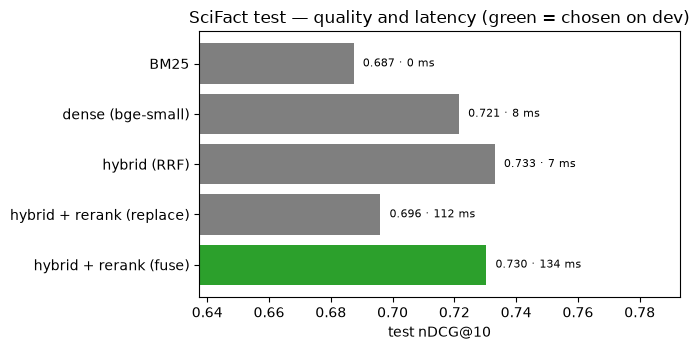

In [47]:
test_rankings = all_pipeline_rankings(test_queries)
test_results = {name: evaluate(test_rankings[name], test_qids, test_rel) for name in PIPELINES}
test_table = pd.DataFrame(test_results).T
test_table["ms / query"] = pd.Series(latency_ms)
test_table["chosen on dev"] = ["✅" if n == chosen else "" for n in test_table.index]
display(test_table.round(4))

fig, ax = plt.subplots(figsize=(7, 3.6))
colors = ["tab:green" if n == chosen else "tab:gray" for n in test_table.index]
ax.barh(test_table.index, test_table["nDCG@10"], color=colors)
for y, (n, r) in enumerate(test_table.iterrows()):
    ax.text(r["nDCG@10"] + 0.003, y, f"{r['nDCG@10']:.3f} · {r['ms / query']:.0f} ms", va="center", fontsize=8)
ax.set(xlabel="test nDCG@10", xlim=(test_table["nDCG@10"].min() - 0.05, test_table["nDCG@10"].max() + 0.06),
       title="SciFact test — quality and latency (green = chosen on dev)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Step 5 — Recommendation (computed)

In [48]:
def per_query_ndcg(name):
    return np.array([ndcg_at_k(r, test_rel[q]) for r, q in zip(test_rankings[name], test_qids)])


def paired_gap(a, b):
    """Mean per-query nDCG@10 difference a − b on test, with a ±2 standard-error band."""
    diff = per_query_ndcg(a) - per_query_ndcg(b)
    return diff.mean(), 2 * diff.std(ddof=1) / math.sqrt(len(diff))


best_test = test_table["nDCG@10"].idxmax()
chosen_row, bm25_row = test_table.loc[chosen], test_table.loc["BM25"]
gap_bm25, band_bm25 = paired_gap(chosen, "BM25")

print(f"1. Pipeline chosen on dev (before seeing test): {chosen}. Test nDCG@10 {chosen_row['nDCG@10']:.3f}, "
      f"Recall@100 {chosen_row['Recall@100']:.3f}, ~{chosen_row['ms / query']:.0f} ms/query on this laptop.")
print(f"2. Versus plain BM25 on the same 300 test queries: {gap_bm25:+.3f} ± {band_bm25:.3f} nDCG@10 "
      f"({'a real improvement' if gap_bm25 - band_bm25 > 0 else 'not clearly better than BM25'}).")
if best_test == chosen:
    print("3. The dev choice is also the best pipeline on test — the decision generalized.")
else:
    gap_best, band_best = paired_gap(best_test, chosen)
    noise = "within noise" if abs(gap_best) < band_best else "larger than the noise band"
    print(f"3. On test, {best_test} scores {gap_best:+.3f} ± {band_best:.3f} higher than the dev choice ({noise}). "
          f"We report the dev choice anyway — switching now would be tuning on test.")
if "rerank" in chosen:
    gap_rr, band_rr = paired_gap(chosen, "hybrid (RRF)")
    extra_ms = latency_ms[chosen] - latency_ms["hybrid (RRF)"]
    if gap_rr - band_rr > 0:
        advice = "the reranker clearly earns its latency"
    else:
        advice = ("its dev gain did not clearly carry over to test, so before paying that latency in production "
                  "I would enlarge the dev set or try an in-domain reranker — otherwise hybrid (RRF) is the cheaper safe default")
    print(f"4. The chosen pipeline's reranker adds ~{extra_ms:.0f} ms/query for {gap_rr:+.3f} ± {band_rr:.3f} nDCG@10 over hybrid → {advice}.")
else:
    gap_rr, band_rr = paired_gap("hybrid + rerank (replace)", "hybrid (RRF)")
    print(f"4. For reference, replacing the hybrid ranking with the MS MARCO cross-encoder changes test nDCG@10 by {gap_rr:+.3f} ± {band_rr:.3f}.")
print(f"5. Recall@100 of the chosen pipeline is {chosen_row['Recall@100']:.3f}: for RAG, the documents the LLM can see are capped by this number.")

1. Pipeline chosen on dev (before seeing test): hybrid + rerank (fuse). Test nDCG@10 0.730, Recall@100 0.962, ~134 ms/query on this laptop.
2. Versus plain BM25 on the same 300 test queries: +0.043 ± 0.023 nDCG@10 (a real improvement).
3. On test, hybrid (RRF) scores +0.003 ± 0.018 higher than the dev choice (within noise). We report the dev choice anyway — switching now would be tuning on test.
4. The chosen pipeline's reranker adds ~127 ms/query for -0.003 ± 0.018 nDCG@10 over hybrid → its dev gain did not clearly carry over to test, so before paying that latency in production I would enlarge the dev set or try an in-domain reranker — otherwise hybrid (RRF) is the cheaper safe default.
5. Recall@100 of the chosen pipeline is 0.962: for RAG, the documents the LLM can see are capped by this number.


**Stretch goals**
1. Replace bge-small in the hybrid with your **fine-tuned MiniLM** from section 14. Does the best pipeline change?
2. Try a larger or domain-specific reranker, or fine-tune the cross-encoder with `CrossEncoderTrainer` on SciFact training pairs, and re-run steps 3–4.
3. Add a **weighted-score** fusion (min-max normalized BM25 + cosine, weight tuned on dev) and compare it with RRF.
4. Serve the chosen pipeline behind a FastAPI endpoint with the FAISS index in its own process, and measure p95 latency under concurrent requests.

### 🗣️ How to talk about this in an interview
- "I built BM25, dense, hybrid (RRF), and reranked pipelines on BEIR SciFact and evaluated them with nDCG@10, Recall@100 and MRR using metric code I verified against scikit-learn and sentence-transformers."
- "I made every choice — the model, RRF k, whether to rerank — on a dev split of the training queries, with a rule written before looking, and reported test once."
- "Hybrid search beat either retriever alone because BM25 wins on exact scientific terms and dense wins on paraphrases; I checked that per query, not just on the average."
- "I didn't assume the MS MARCO cross-encoder would help on scientific claims: I compared its dev and test gains with paired per-query confidence bands against its ~100 ms per query, and would fine-tune an in-domain reranker before paying that latency."
- "For scale I benchmarked FAISS Flat vs HNSW vs IVF on 200k real vectors and showed binary quantization plus rescoring keeps most of the quality at 32× less memory."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is the difference between a bi-encoder and a cross-encoder? When do you use each?**

<details><summary>Show answer</summary>

- **30-second answer:** A bi-encoder embeds query and document separately into vectors compared with cosine — documents are embedded once, so it scales to millions of documents. A cross-encoder feeds the query and document together through one transformer and outputs a relevance score — more accurate, but it needs a forward pass per pair. Use bi-encoders (plus BM25) for first-stage retrieval and cross-encoders to rerank the top-k.
- **Go deeper:** Late-interaction models like ColBERT sit in between (per-token vectors, MaxSim scoring). Cross-encoder scores are logits, not calibrated; rerank depth (e.g. 20–100) trades recall for latency. Always verify a reranker helps on in-domain labels.
- **❌ Common wrong answer:** "Cross-encoders are always better, so use them for search." They can't precompute document representations; cost is queries × documents.

</details>

**Q2. Cosine similarity, dot product, or Euclidean distance — does it matter?**

<details><summary>Show answer</summary>

- **30-second answer:** For L2-normalized vectors they produce the same ranking, since ‖a−b‖² = 2 − 2·cos(a, b), so use the dot product for speed. For unnormalized vectors they differ: dot product rewards vector length. Use the similarity function the model was trained with.
- **Go deeper:** Some models are trained for dot product (unnormalized, e.g. some DPR/MS MARCO models), where length carries information. FAISS `IndexFlatIP` on normalized vectors = cosine search. Cosine near 0 means unrelated; negative cosines are rare for sentence embeddings.
- **❌ Common wrong answer:** "A cosine of −1 means opposite meaning." Embedding models aren't trained to place antonyms opposite; "I love it" and "I hate it" are usually close.

</details>

**Q3. How are sentence embedding models trained?**

<details><summary>Show answer</summary>

- **30-second answer:** Start from a pre-trained transformer, add pooling, and train on pairs so related texts get close vectors. The original SBERT used SNLI/MultiNLI with a softmax classifier over (u, v, |u−v|), then STS regression on cosine similarity. Modern retrieval models (e.g. all-MiniLM-L6-v2, E5, BGE) use contrastive learning with in-batch negatives (InfoNCE / MultipleNegativesRankingLoss) on hundreds of millions to billions of pairs, often followed by fine-tuning with hard negatives.
- **Go deeper:** Bigger batches give more negatives (GradCache / `CachedMultipleNegativesRankingLoss` fakes large batches); hard negatives mined with BM25 or a previous model matter a lot; watch for false negatives. Instruction/prefix-trained models (E5, BGE) need the same prompts at inference. MatryoshkaLoss makes truncation cheap.
- **❌ Common wrong answer:** "SBERT was trained with TripletLoss on NLI." SBERT's NLI training used a softmax classification objective; the triplet objective was a separate experiment.

</details>

**Q4. Explain HNSW and IVF. Which knobs trade recall for speed?**

<details><summary>Show answer</summary>

- **30-second answer:** HNSW builds a multi-layer proximity graph; search greedily walks from a sparse top layer down to the dense bottom layer. `M` = links per node, `efConstruction` = build-time candidate list, `efSearch` = query-time candidate list (higher → better recall, slower). IVF clusters vectors into `nlist` cells with k-means and scans only the `nprobe` closest cells at query time (higher `nprobe` → better recall, slower).
- **Go deeper:** HNSW: best recall/latency, high memory (links), slow build, deletions are hard. IVF: fast build, low overhead, combine with PQ (IVF-PQ) for billion-scale memory budgets; needs representative training data. Evaluate recall@k against exact search at your target latency (as in section 11).
- **❌ Common wrong answer:** "ANN indexes are exact, just faster" or "increase `efConstruction` to speed up queries."

</details>

**Q5. Why use hybrid search, and how does reciprocal rank fusion work?**

<details><summary>Show answer</summary>

- **30-second answer:** BM25 is strong on exact terms (names, codes, rare words) and dense retrieval on paraphrases and synonyms; they fail on different queries, so combining them improves recall and ranking. RRF sums 1/(k + rank) over each ranked list (k ≈ 60) — it uses ranks only, so no score normalization is needed.
- **Go deeper:** Alternatives: weighted sum of min-max or z-normalized scores (needs tuning per corpus), learned fusion, or SPLADE-style learned sparse vectors. Tune k or weights on a dev set. In RAG, hybrid retrieval notably helps with acronyms, product IDs, and numbers.
- **❌ Common wrong answer:** "Just add the BM25 score and the cosine." Different scales (0–40 vs 0–1) make one dominate.

</details>

**Q6. Recall@k, MRR, nDCG — what does each measure, and which matters for RAG?**

<details><summary>Show answer</summary>

- **30-second answer:** Recall@k: share of relevant documents found in the top k. MRR: 1/rank of the first relevant document, averaged. nDCG@k: position-discounted gain (1/log₂(rank+1)) normalized by the ideal ranking, supporting graded relevance. For RAG, recall@k (with k = what fits in the context) is the retriever's ceiling; nDCG/MRR matter when order matters or context is tight.
- **Go deeper:** Report several metrics and per-query distributions; use paired comparisons (same queries) and bootstrap confidence intervals for small query sets; beware of unlabeled relevant documents (false negatives in qrels) in benchmarks.
- **❌ Common wrong answer:** "Accuracy" or "precision@k is enough" — with 1–2 relevant docs per query, precision@10 is tiny even for a perfect system.

</details>

**Q7. What are embedding quantization and Matryoshka embeddings, and what do they cost?**

<details><summary>Show answer</summary>

- **30-second answer:** Quantization stores fewer bits per dimension: int8 (4× smaller, small quality loss) or binary (32× smaller, compared with fast Hamming distance, usually followed by rescoring top candidates with higher-precision vectors). Matryoshka Representation Learning trains models so the first dimensions carry the most information, so you can truncate (e.g. 1024 → 256) with modest loss.
- **Go deeper:** int8 needs calibration ranges from representative data. Binary + rescoring recovers much of the loss while keeping only bits in RAM. Compare truncation at equal compression factors and in absolute quality at your memory budget (section 12 does both). Product quantization (PQ) is the index-side alternative.
- **❌ Common wrong answer:** "You can truncate any embedding model's vectors" or "binary quantization is lossless."

</details>

### 💻 Coding

**Q8. Implement top-k cosine search over a large embedding matrix efficiently.**

<details><summary>Show answer</summary>

- **30-second answer:** Normalize corpus rows once; for a batch of queries normalize, compute `scores = Q @ C.T`, use `np.argpartition(-scores, k, axis=1)[:, :k]` (O(N)) and sort only those k. For large corpora process the corpus in chunks to bound memory, and use float32.
- **Go deeper:** `(Q @ C.T)` for 1,000 queries × 10M docs is 10¹⁰ floats (40 GB) — chunk it. On GPU use `torch.topk`. Beyond ~1M vectors or strict latency, use an ANN index. This notebook's `cosine_top_k` is asserted against `util.semantic_search`.
- **❌ Common wrong answer:** Full `argsort` of every row (O(N log N)), or looping over documents in Python.

</details>

**Q9. Implement MultipleNegativesRankingLoss (in-batch negatives) given query and passage embeddings.**

<details><summary>Show answer</summary>

- **30-second answer:** Normalize both, `logits = scale * Q @ P.T` (B×B), `loss = cross_entropy(logits, arange(B))` — each query's positive is its own row index; all other passages in the batch are negatives. `scale` (≈ 20) is the inverse temperature.
- **Go deeper:** Add hard negatives as extra columns (B × 2B logits); symmetric variants also compute passage→query loss; duplicates in a batch create false negatives (use a no-duplicates sampler). Practice exercise 6 implements it in NumPy and checks against PyTorch.
- **❌ Common wrong answer:** Using `arange(B)` labels with an unnormalized dot product and no scale, or forgetting that duplicate positives in a batch are treated as negatives.

</details>

### 🐛 Debugging Scenarios

**Q10. After a "harmless" refactor, retrieval quality collapsed but nothing errors. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** That queries and documents use the **same model and version**; the same **normalization** and similarity; the right **prompts/prefixes** (`query:` / `passage:`); the same **pooling** and `max_seq_length`; and that document IDs still map to the right rows in the index.
- **Go deeper:** Keep a small golden query set with expected results as a CI check; store model name, revision, dimension, and preprocessing config alongside the index; re-embed the corpus when anything changes. Pitfall 1 shows mixed models give near-zero nDCG without any error.
- **❌ Common wrong answer:** "The vector database is broken" — the vectors are usually the problem.

</details>

**Q11. Your fine-tuned embedding model shows +20 points offline, but users see no improvement. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** The evaluation probably leaked: evaluated on training queries (or near-duplicates), on documents that were paired during training, or on synthetic queries that don't look like real user queries. Evaluate on held-out, de-duplicated, real queries.
- **Go deeper:** Also check: index not re-embedded with the new model, distribution shift (users ask differently than your training pairs), regressions on general queries (catastrophic forgetting), and false negatives in the labels. Pitfall 4 measures the training-query inflation.
- **❌ Common wrong answer:** "Users are wrong" or "train longer."

</details>

**Q12. You added a cross-encoder reranker and nDCG dropped. What could be going on?**

<details><summary>Show answer</summary>

- **30-second answer:** Domain mismatch (e.g. an MS MARCO web-search reranker on scientific claims or legal text), passages truncated at the reranker's max length, rerank depth too small to find new documents or too large so noise enters, or the first stage already stronger than the reranker on this domain.
- **Go deeper:** Evaluate rerank depth on dev, fuse reranker ranks with first-stage ranks (RRF) instead of replacing, use a domain or larger reranker, or fine-tune it with `CrossEncoderTrainer` on in-domain pairs with hard negatives. Section 10 and the mini project measure this on SciFact.
- **❌ Common wrong answer:** "Rerankers always improve results, so the evaluation must be wrong."

</details>

### 🏗️ Design

**Q13. Design the retrieval layer for a RAG assistant over 20 million internal documents with a p95 latency budget of 300 ms.**

<details><summary>Show answer</summary>

- **30-second answer:** Chunk documents (~200–500 tokens with overlap, keep titles/metadata), embed with a model chosen on a labeled sample of real queries, index in an ANN store (HNSW, or IVF-PQ if memory-bound; int8/binary + rescoring to cut RAM), run BM25 in parallel and fuse with RRF, rerank the top ~50 with a cross-encoder if it helps on dev within budget, apply permission/metadata filters, and return top ~5–10 chunks with citations.
- **Go deeper:** Offline eval set (recall@k, nDCG) + online metrics (click/answer acceptance); embedding versioning and background re-indexing; caching frequent queries; freshness via incremental upserts; sharding; per-stage latency budgets (e.g. 30 ms embed, 20 ms ANN, 20 ms BM25, 150 ms rerank); monitor empty/low-score retrievals.
- **❌ Common wrong answer:** "Put everything in a vector DB and take top-3 by cosine" — no evaluation, no hybrid, no chunking strategy, no access control.

</details>

**Q14. When would you fine-tune an embedding model versus changing models or adding BM25/reranking?**

<details><summary>Show answer</summary>

- **30-second answer:** First try cheap changes measured on a dev set: a better off-the-shelf model, correct prompts, chunking, hybrid search, and reranking. Fine-tune when the domain vocabulary is specialized, you have (or can generate) a few thousand in-domain query–passage pairs, and the gap to the target persists — then evaluate on held-out queries.
- **Go deeper:** Synthetic data: generate queries per chunk with an LLM, filter with a cross-encoder, mine hard negatives. Costs: re-embedding the whole corpus, maintaining a custom model. Fine-tuning a reranker can be cheaper than re-indexing, since documents don't need re-embedding.
- **❌ Common wrong answer:** "Always fine-tune" or "never fine-tune, just use the biggest model."

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** Two unit vectors have cosine similarity `0.8`. What is their Euclidean distance (3 decimals)?
<details><summary>Answer</summary>

`0.632` — √(2 − 2·0.8) = √0.4.
</details>

**2.** RRF score (k = 60) of a document ranked 1st by BM25 and 3rd by the dense retriever?
<details><summary>Answer</summary>

`0.03227` — 1/61 + 1/63 = 0.016393 + 0.015873.
</details>

**3.** How much RAM do 1,000,000 × 384-dim `float32` embeddings need, and how much as `ubinary`?
<details><summary>Answer</summary>

`1.536 GB` (10⁶ × 384 × 4 bytes) and `48 MB` (384 bits = 48 bytes per vector).
</details>

**4.** `quantize_embeddings(np.random.randn(10, 16).astype("float32"), "ubinary").shape`
<details><summary>Answer</summary>

`(10, 2)` — 16 bits packed into 2 bytes per vector, dtype `uint8`.
</details>

**5.** `sklearn.metrics.ndcg_score([[1, 0, 0, 1, 0]], [[0.9, 0.8, 0.7, 0.6, 0.5]], k=3)`
<details><summary>Answer</summary>

`≈ 0.613` — the top 3 contain one relevant doc (rank 1): DCG = 1; ideal DCG@3 with two relevant docs = 1 + 1/log₂3 ≈ 1.631; 1/1.631 ≈ 0.613.
</details>

## 📚 Resources

### 📖 Official Docs
- [Sentence Transformers documentation](https://www.sbert.net/) — models, `encode_query`/`encode_document`, training, evaluators
- [Sentence Transformers — Retrieve & Re-Rank](https://sbert.net/examples/sentence_transformer/applications/retrieve_rerank/README.html) — the bi-encoder + cross-encoder pattern
- [Hugging Face blog — Training and Finetuning Embedding Models with Sentence Transformers](https://huggingface.co/blog/train-sentence-transformers) — `SentenceTransformerTrainer`, losses, evaluators
- [Hugging Face blog — Binary and Scalar Embedding Quantization](https://huggingface.co/blog/embedding-quantization) — int8/binary with rescoring, with benchmarks
- [Faiss wiki — Faiss indexes](https://github.com/facebookresearch/faiss/wiki/Faiss-indexes) — every index type and its parameters
- [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard) — compare embedding models by task, size, and language
- [BEIR SciFact on the Hugging Face Hub](https://huggingface.co/datasets/BeIR/scifact) — the benchmark used here

### 🎥 Videos
- [James Briggs — HNSW for Vector Search Explained and Implemented with Faiss](https://www.youtube.com/watch?v=QvKMwLjdK-s) (~35 min) — clear walkthrough of the HNSW graph and its parameters with FAISS code
- [Pinecone — Graph-Based Approximate Nearest Neighbors (ANN) and HNSW](https://www.youtube.com/watch?v=4PsyNdFlxmk) (~59 min) — workshop with HNSW's author Yury Malkov; go deeper after section 11
- [Stanford CS25 — Retrieval Augmented Language Models](https://www.youtube.com/watch?v=mE7IDf2SmJg) (~1 h 19 min, Douwe Kiela) — where retrieval fits in RAG, from one of the authors of the original RAG paper

### 📄 Papers
- [Reimers & Gurevych (2019) — Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks](https://arxiv.org/abs/1908.10084)
- [Thakur et al. (2021) — BEIR: A Heterogenous Benchmark for Zero-shot Evaluation of Information Retrieval Models](https://arxiv.org/abs/2104.08663)
- [Muennighoff et al. (2022) — MTEB: Massive Text Embedding Benchmark](https://arxiv.org/abs/2210.07316)
- [Karpukhin et al. (2020) — Dense Passage Retrieval for Open-Domain Question Answering](https://arxiv.org/abs/2004.04906) — in-batch negatives for retrieval
- [Malkov & Yashunin (2016) — Efficient and robust approximate nearest neighbor search using Hierarchical Navigable Small World graphs](https://arxiv.org/abs/1603.09320)
- [Kusupati et al. (2022) — Matryoshka Representation Learning](https://arxiv.org/abs/2205.13147)
- [Khattab & Zaharia (2020) — ColBERT: Efficient and Effective Passage Search via Contextualized Late Interaction over BERT](https://arxiv.org/abs/2004.12832)
- [Cormack, Clarke & Büttcher (2009) — Reciprocal Rank Fusion outperforms Condorcet and individual Rank Learning Methods (PDF)](https://plg.uwaterloo.ca/~gvcormac/cormacksigir09-rrf.pdf)

### 📘 Books & Courses
- [Pinecone — Faiss: The Missing Manual (free)](https://www.pinecone.io/learn/series/faiss/) — indexes, PQ, HNSW, and IVF explained with code
- [Vicki Boykis — What are embeddings? (free book)](https://vickiboykis.com/what_are_embeddings/) — history and intuition from one-hot vectors to transformers

### 🏋️ Practice
- [BEIR benchmark repository](https://github.com/beir-cellar/beir) — 18 retrieval datasets: repeat the shoot-out on FiQA or NFCorpus
- [bm25s](https://github.com/xhluca/bm25s) — the fast BM25 library used here, with benchmark scripts to reproduce

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Similarity | compare vectors | cosine = a·b / (‖a‖‖b‖); unit vectors: ‖a−b‖² = 2 − 2cos |
| Contextual → sentence | one vector per text | mean pooling with attention mask, or CLS; then `Normalize` |
| Sentence Transformers | encode & compare | `SentenceTransformer(name)`, `encode_query`, `encode_document`, `similarity`, `prompt=` |
| Bi- vs cross-encoder | retrieve vs rerank | bi: precompute docs; `CrossEncoder(name).predict(pairs)` / `.rank(query, docs)` |
| Model choice | shortlist then measure | MTEB retrieval tab → nDCG@10 on your dev queries; mind prefixes and max length |
| Semantic search | exact top-k | `Q @ D.T` + `np.argpartition`; `util.semantic_search` |
| Metrics | quality | Recall@k, MRR@k, nDCG@k; `ndcg_score`, `InformationRetrievalEvaluator` |
| BM25 | keyword ranking | `bm25s.BM25().index(bm25s.tokenize(docs, stopwords="en", stemmer=...))` |
| Hybrid | combine retrievers | RRF: Σ 1/(k + rank), k = 60 |
| Reranking | reorder top-k | cross-encoder on top 20–100; verify on dev; replace or fuse |
| FAISS | ANN indexes | `IndexFlatIP`, `IndexHNSWFlat(d, M)` + `efSearch`, `IndexIVFFlat(q, d, nlist)` + `nprobe` (separate process on macOS with torch) |
| Quantization / MRL | shrink memory | `quantize_embeddings(x, "int8"/"ubinary")`, Hamming + rescoring; `truncate_dim=` |
| Clustering | explore structure | `KMeans`, `adjusted_rand_score`, PCA / t-SNE for plots only |
| Fine-tuning | adapt to domain | `SentenceTransformerTrainer` + `MultipleNegativesRankingLoss` + `BatchSamplers.NO_DUPLICATES`; eval on held-out queries |

## ➡️ What's Next

**[03 · Hugging Face Transformers](03_HuggingFace_Transformers.ipynb)** — you've used transformer encoders as ready-made embedding models; next you'll load, fine-tune, and evaluate transformers for classification and other tasks with the current `Trainer` API — the same skills you'll need to fine-tune rerankers and LLMs later.